# Multi-Source Metadata Concordance & Resolution Analysis: HAMLET vs. MLMarker 1409
## Evaluating Healthy Native Human Tissues, Lin IC Semantic Resolution for Out-of-Vocabulary Annotations, In Vitro Cultured Fibroblast Drift, and Disease Impact

### Executive Summary & Objectives
  
1. **HAMLET (Normalized LLM Text-Mining Pipeline)**: Canonical ontology-normalized sample metadata extracted from full-text manuscripts and PRIDE project descriptions (`HAMLET_normalized.tsv` / `PATH_NORM`). Annotations operate at the **project level** (`source_file` / PXD).
2. **MLMarker (Expression-Based Classifier, 1409 Release)**: Predicts tissue of origin directly from quantitative DIA-NN/FlashLFQ/NSAF proteomic expression matrices (`run_meta_mlmarker_all.tsv` / `PATH_MLM`). Annotations operate at the **run level**.



## 1. Setup, Environment & Path Configuration
We load all required libraries, set scientific plot aesthetics, and define canonical paths.


In [1]:
import os
import sys
import re
import ast
import math
import warnings
from io import StringIO
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle, Ellipse, FancyBboxPatch
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from scipy import stats

try:
    from IPython.display import display
except ImportError:
    display = print

warnings.filterwarnings('ignore')

# Configure publication plot aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['grid.color'] = '#eeeeee'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['figure.dpi'] = 120

# ── Primary Data Paths ──
PATH_NORM = r"/home/tine/git/Publication/textmining/mlmarker_hamlet/output/HAMLET_normalized.tsv"
PATH_MLM = r"/home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/run_meta_mlmarker_all_penalty.tsv"
PATH_TRAINING = r"/home/tine/git/Publication/textmining/MLMarker/Training_PXDs/SupplementaryTableS1.tsv"

PATH_ONTOLOGY_DIR = r"/home/tine/git/Publication/textmining/mlmarker_hamlet/input/ontologies"
PATH_OUTPUT = r"/home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET"

os.makedirs(PATH_OUTPUT, exist_ok=True)
os.makedirs(PATH_ONTOLOGY_DIR, exist_ok=True)

print(f"Environment configured.")
print(f"  PATH_NORM:     {PATH_NORM}")
print(f"  PATH_MLM:      {PATH_MLM}")
print(f"  PATH_TRAINING: {PATH_TRAINING}")
print(f"  PATH_OUTPUT:   {PATH_OUTPUT}")


Environment configured.
  PATH_NORM:     /home/tine/git/Publication/textmining/mlmarker_hamlet/output/HAMLET_normalized.tsv
  PATH_MLM:      /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/run_meta_mlmarker_all_penalty.tsv
  PATH_TRAINING: /home/tine/git/Publication/textmining/MLMarker/Training_PXDs/SupplementaryTableS1.tsv
  PATH_OUTPUT:   /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET


## 2. Multi-Cohort Data Ingestion & Biological Stratification
We load HAMLET and MLMarker predictions, exclude the 183 MLMarker training PXDs, parse all normalized entity fields, and stratify into three experimental cohorts:
1. **Cohort A (Healthy Native Human Tissue)**: Strictly `Homo sapiens`, healthy disease state (`normal`, `disease free`, `healthy`, `control`, no cancer), and non-cell-culture native samples.
2. **Cohort B (Healthy Skin Focus — Native vs. Cultured Fibroblasts)**: All skin-origin projects to evaluate proteomic drift during in vitro culture.
3. **Cohort C (Cancer / Diseased Human Tissue)**: Human cancer and pathological tissues to quantify disease-induced classification degradation.


In [2]:
# 1. Load MLMarker training PXDs (SupplementaryTableS1.tsv)
with open(PATH_TRAINING, "r", encoding="utf-8") as f:
    training_pxds = set(
        token for token in f.read().split()
        if token.startswith("PXD") and token != "PXD_accession"
    )
print(f"Loaded {len(training_pxds)} MLMarker training PXDs to exclude from evaluation.")

# 2. Load and clean MLMarker 1409 predictions
df_mlm_raw = pd.read_csv(PATH_MLM, sep="\t", low_memory=False)
df_mlm_clean = df_mlm_raw.drop_duplicates(subset=['pxd', 'run'], keep='first').copy()
# Exclude training PXDs
df_mlm_unseen = df_mlm_clean[~df_mlm_clean['pxd'].isin(training_pxds)].copy()
print(f"MLMarker 1409 Unseen Runs: {len(df_mlm_unseen):,} across {df_mlm_unseen['pxd'].nunique():,} projects (from {len(df_mlm_clean):,} raw).")

# 3. Load HAMLET normalized metadata
df_norm_raw = pd.read_csv(PATH_NORM, sep="\t", low_memory=False)
df_norm_unseen = df_norm_raw[~df_norm_raw['source_file'].isin(training_pxds)].copy()
print(f"HAMLET Unseen Projects:    {len(df_norm_unseen):,} (from {len(df_norm_raw):,} raw).")

# Generalized term extractor for dicts, lists, and strings
def extract_norm_terms(cell):
    if pd.isna(cell) or cell is None:
        return []
    if isinstance(cell, str):
        try:
            val = ast.literal_eval(cell)
        except Exception:
            val = cell
    else:
        val = cell

    if isinstance(val, dict):
        ont = val.get("ontology_name")
        v = ont if (ont is not False and ont is not None and str(ont).lower() != 'false') else val.get("value")
        if v and str(v).lower() not in ["unknown", "none", "false", "nan", ""]:
            return [str(v).strip()]
        return []
    elif isinstance(val, list):
        items = []
        for x in val:
            if isinstance(x, dict):
                ont = x.get("ontology_name")
                v = ont if (ont is not False and ont is not None and str(ont).lower() != 'false') else x.get("value")
                if v and str(v).lower() not in ["unknown", "none", "false", "nan", ""]:
                    items.append(str(v).strip())
            elif isinstance(x, str) and str(x).lower() not in ["unknown", "none", "false", "nan", ""]:
                items.append(str(x).strip())
        return list(dict.fromkeys(items))
    elif isinstance(val, str) and val.lower() not in ["unknown", "none", "false", "nan", ""]:
        return [val.strip()]
    return []

# Parse entity columns
for col in ['tissue', 'species', 'disease_state', 'sample_source', 'cell_type', 'cell_line']:
    df_norm_unseen[f'{col}_list'] = df_norm_unseen[col].apply(extract_norm_terms)
    df_norm_unseen[f'{col}_llm'] = df_norm_unseen[f'{col}_list'].apply(lambda l: "; ".join(l) if l else None)

# Filter Human
is_human = df_norm_unseen['species_list'].apply(lambda l: any('homo sapiens' in s.lower() for s in l))
df_human = df_norm_unseen[is_human].copy()

# Cell culture detector
def is_cell_culture(row):
    all_text = " ".join(row['sample_source_list'] + row['cell_type_list'] + row['cell_line_list']).lower()
    return any(k in all_text for k in ['cell culture', 'cell line', 'cultured cell', 'in vitro', 'fibroblast', 'recombinant', 'explants', 'organoid'])

# Disease / Cancer detector
def is_healthy_disease(row):
    d_text = " ".join(row['disease_state_list']).lower()
    has_healthy = any(k in d_text for k in ['normal', 'disease free', 'healthy', 'control'])
    has_disease = any(k in d_text for k in ['cancer', 'tumor', 'carcinoma', 'melanoma', 'leukemia', 'neoplasm', 'adenocarcinoma', 'lymphoma', 'glioma', 'sarcoma', 'adenoma', 'syndrome', 'disease', 'inflammation', 'infection'])
    return has_healthy and not has_disease

def is_cancer_disease(row):
    d_text = " ".join(row['disease_state_list']).lower()
    return any(k in d_text for k in ['cancer', 'tumor', 'carcinoma', 'melanoma', 'leukemia', 'neoplasm', 'adenocarcinoma', 'lymphoma', 'glioma', 'sarcoma'])

df_human['is_culture'] = df_human.apply(is_cell_culture, axis=1)
df_human['is_healthy'] = df_human.apply(is_healthy_disease, axis=1)
df_human['is_cancer'] = df_human.apply(is_cancer_disease, axis=1)

# Cohort A: Healthy Native Human
cohort_a = df_human[df_human['is_healthy'] & ~df_human['is_culture'] & df_human['tissue_llm'].notna()].copy()

# Cohort B: All Skin Projects (Native vs Culture)
is_skin = df_human['tissue_list'].apply(lambda l: any('skin' in t.lower() or 'dermis' in t.lower() for t in l))
cohort_b_skin = df_human[is_skin].copy()

# Cohort C: Cancer / Diseased Human
cohort_c_cancer = df_human[df_human['is_cancer'] & df_human['tissue_llm'].notna()].copy()

print(f"\n--- Cohort Breakdown (Unseen Human Projects) ---")
print(f"Cohort A (Healthy Native Human Tissue): {len(cohort_a):,} projects")
print(f"Cohort B (All Skin Projects):            {len(cohort_b_skin):,} projects ({cohort_b_skin['is_culture'].sum()} cultured, {(~cohort_b_skin['is_culture']).sum()} native)")
print(f"Cohort C (Cancer / Diseased Human):     {len(cohort_c_cancer):,} projects")

# Merge onto MLMarker runs for Cohort A (Primary Benchmark)
df_merged_healthy = df_mlm_unseen.merge(
    cohort_a[['source_file', 'tissue_llm', 'tissue_list', 'disease_state_llm', 'sample_source_llm', 'biological_confidence_overall']],
    left_on='pxd', right_on='source_file', how='inner'
).copy()
df_merged_healthy.rename(columns={'tissue': 'tissue_mlm', 'confidence': 'confidence_mlm'}, inplace=True)

print(f"\nPrimary Healthy Native Cohort: {len(df_merged_healthy):,} runs across {df_merged_healthy['pxd'].nunique():,} projects.")


Loaded 183 MLMarker training PXDs to exclude from evaluation.


MLMarker 1409 Unseen Runs: 56,094 across 1,149 projects (from 62,329 raw).


HAMLET Unseen Projects:    1,598 (from 1,737 raw).



--- Cohort Breakdown (Unseen Human Projects) ---
Cohort A (Healthy Native Human Tissue): 79 projects
Cohort B (All Skin Projects):            50 projects (45 cultured, 5 native)
Cohort C (Cancer / Diseased Human):     393 projects

Primary Healthy Native Cohort: 3,135 runs across 65 projects.


## 3. UBERON / CL Ontology DAG Construction & Lin Information Content (IC) Engine
To evaluate semantic agreement rigorously and maintain 100% mathematical and topological parity with our benchmark knowledge graph (`Try_distance_3D_GraphIC.ipynb` / `SciBERT_tissue_similarity.ipynb`):
1. **Targeted Knowledge Graph Construction**: Parses `uberon_basic.obo` and `cl.obo`, filtering out blocked prefixes (`NCBITaxon`, `CARO`, `PATO`, `IAO`, `STATO`, `SO`, `PR`, `CHEBI`) and pruning 16 generic high-degree hubs and developmental root nodes (`UBERON:0000062` *organ*, `UBERON:0000078` *organism substance*, `UBERON:0004120` *mesoderm-derived structure*, BFO roots).
2. **Directed Anatomical Relations**: Links concepts directed child $\rightarrow$ parent via biological relations (`is_a`, `part_of`, `subdivision_of`, `located_in`, `composed_primarily_of`, `secreted_by`, `produces`, `produced_by`, `connected_to`, `continuous_with`, `develops_from`, `develops_in`, `sexually_homologous_to`, `transformation_of`).
3. **Graph-Theoretic Information Content (IC)**:
   $$\text{IC}(c) = -\log_2\left(\frac{|\text{descendants}(c \text{ in } G_{\text{rev}})| + 1}{N}\right)$$
   where $G_{\text{rev}}$ inverts child $\rightarrow$ parent edges into parent $\rightarrow$ child hierarchies, and $N = |V(G_{\text{directed}})|$.
4. **Lin's Semantic Similarity**:
   $$\text{Sim}_{\text{Lin}}(A, B) = \frac{2 \times \text{IC}(\text{MICA}(A, B))}{\text{IC}(A) + \text{IC}(B)}$$
   where $\text{MICA}(A, B) = \arg\max_{c \in \text{anc}(A) \cap \text{anc}(B)} \text{IC}(c)$. Transitive ancestors are retrieved via topological descendants in $G_{\text{directed}}$ filtered to anatomical and cellular prefixes (`UBERON:`, `CL:`, `BFO:`).


In [3]:
# Check/download UBERON and CL OBO files
uberon_obo_path = os.path.join(PATH_ONTOLOGY_DIR, "uberon_basic.obo")
cl_obo_path = os.path.join(PATH_ONTOLOGY_DIR, "cl.obo")

if not os.path.exists(uberon_obo_path):
    print("Downloading UBERON basic OBO...")
    r = requests.get("http://purl.obolibrary.org/obo/uberon/basic.obo", stream=True)
    with open(uberon_obo_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192): f.write(chunk)

if not os.path.exists(cl_obo_path):
    print("Downloading Cell Ontology (CL) OBO...")
    r = requests.get("http://purl.obolibrary.org/obo/cl.obo", stream=True)
    with open(cl_obo_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192): f.write(chunk)

RELATION_WEIGHTS = {
    'is_a': 1.0,
    'part_of': 1.0, 'BFO:0000050': 1.0,
    'has_part': 1.0, 'BFO:0000051': 1.0,
    'subdivision_of': 1.0,
    'located_in': 0.8, 'RO:0001025': 0.8,
    'location_of': 0.8, 'RO:0001015': 0.8,
    'composed_primarily_of': 1.1, 'RO:0002473': 1.1,
    'secreted_by': 1.2,
    'produces': 1.2, 'RO:0003000': 1.2,
    'produced_by': 1.2, 'RO:0003001': 1.2,
    'connected_to': 1.3, 'RO:0002150': 1.3,
    'continuous_with': 1.3,
    'develops_from': 1.5, 'RO:0002202': 1.5,
    'develops_in': 1.5, 'RO:0002203': 1.5,
    'sexually_homologous_to': 1.5,
    'transformation_of': 1.5, 'RO:0002494': 1.5
}

BLOCKED_PREFIXES = {'NCBITaxon', 'CARO', 'PATO', 'IAO', 'STATO', 'SO', 'PR', 'http', 'https', 'CHEBI'}
BLOCKED_NODES = {
    'UBERON:0000062', 'UBERON:0000064', 'UBERON:0000061', 'UBERON:0000465', 'UBERON:0001062',
    'UBERON:0000475', 'UBERON:0000479', 'UBERON:0000478', 'UBERON:0015212', 'UBERON:0004121',
    'UBERON:0004120', 'UBERON:0004119', 'UBERON:0000078', 'BFO:0000002', 'BFO:0000004', 'BFO:0000040',
}

def build_knowledge_graph(use_blocked_nodes=True):
    G_dir = nx.DiGraph()
    G_undir = nx.Graph()
    n2i = {}
    i2n = {}

    for obo_file in [uberon_obo_path, cl_obo_path]:
        print(f"Building filtered graph from {os.path.basename(obo_file)}...")
        with open(obo_file, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
        
        term_pattern = re.compile(r'\[Term\](.*?)(?=\n\[|\Z)', re.DOTALL)
        for block in term_pattern.findall(content):
            lines = block.strip().split('\n')
            node_id, name = None, None
            synonyms, parents = [], []
            is_obsolete = False
            
            for line in lines:
                line = line.strip()
                if line.startswith('id:'):
                    node_id = line[3:].strip()
                elif line.startswith('name:'):
                    name = line[5:].strip()
                elif line.startswith('synonym:'):
                    m = re.search(r'"([^"]+)"', line)
                    if m:
                        synonyms.append(m.group(1))
                elif line.startswith('is_a:'):
                    pid = line[5:].split('!')[0].strip().split('{')[0].strip()
                    parents.append((pid, 'is_a'))
                elif line.startswith('relationship:'):
                    parts = line[13:].strip().split()
                    if len(parts) >= 2:
                        rel_type = parts[0]
                        pid = parts[1].split('!')[0].strip().split('{')[0].strip()
                        parents.append((pid, rel_type))
                elif line.startswith('is_obsolete:') and 'true' in line.lower():
                    is_obsolete = True
            
            if node_id and name and not is_obsolete:
                prefix = node_id.split(':')[0] if ':' in node_id else ''
                if prefix in BLOCKED_PREFIXES:
                    continue
                if use_blocked_nodes and node_id in BLOCKED_NODES:
                    continue
                
                G_dir.add_node(node_id, name=name)
                G_undir.add_node(node_id, name=name)
                i2n[node_id] = name
                n2i[name.lower().strip()] = node_id
                for s in synonyms:
                    n2i[s.lower().strip()] = node_id
                
                for pid, rel in parents:
                    p_prefix = pid.split(':')[0] if ':' in pid else ''
                    if p_prefix in BLOCKED_PREFIXES or 'taxon' in rel.lower():
                        continue
                    if use_blocked_nodes and pid in BLOCKED_NODES:
                        continue
                    if rel in RELATION_WEIGHTS or rel.startswith('is_a'):
                        base_w = RELATION_WEIGHTS.get(rel, 1.0)
                        G_dir.add_edge(node_id, pid, relation=rel, weight=base_w)
                        G_undir.add_edge(node_id, pid, relation=rel, weight=base_w)

    return G_dir, G_undir, n2i, i2n

print("Building knowledge graph...")
G_directed, G_undirected, name_to_id, id_to_name = build_knowledge_graph(True)
G_ontology = G_directed
print(f"Knowledge Graph: {len(G_directed):,} nodes, {G_directed.number_of_edges():,} directed edges, {G_undirected.number_of_edges():,} undirected edges.")

# Pre-compute Information Content (IC) map from ontology DAG structure
print("Computing DAG Information Content (IC) map across all entities...")
rev_G = G_directed.reverse()
_total_nodes = len(G_directed)
_ic_map = {}
for node in G_directed.nodes():
    try:
        desc_count = len(nx.descendants(rev_G, node)) + 1
        _ic_map[node] = -math.log2(desc_count / _total_nodes)
    except Exception:
        _ic_map[node] = 1.0

print(f"Pre-computed IC for {len(_ic_map):,} concepts. Max IC = {max(_ic_map.values()):.2f}, Min IC = {min(_ic_map.values()):.2f}")

VALID_ANCESTOR_PREFIXES = {'UBERON:', 'CL:', 'BFO:'}
_anc_cache = {}

def get_filtered_ancestors(curie):
    """Transitive ancestors filtered to anatomical/cellular terms."""
    if curie not in _anc_cache:
        try:
            raw_anc = nx.descendants(G_directed, curie) | {curie}
            _anc_cache[curie] = {a for a in raw_anc if any(str(a).startswith(p) for p in VALID_ANCESTOR_PREFIXES)}
        except Exception:
            _anc_cache[curie] = {curie}
    return _anc_cache[curie]

_lin_cache = {}

def compute_lin_similarity(id_a, id_b):
    pair = (id_a, id_b)
    if pair in _lin_cache:
        return _lin_cache[pair]
    if (id_b, id_a) in _lin_cache:
        return _lin_cache[(id_b, id_a)]
        
    if not id_a or not id_b:
        res = {'lin_sim': np.nan, 'lin_dist': np.nan, 'mica': 'N/A', 'mica_id': None, 'mica_ic': np.nan, 'ic_a': np.nan, 'ic_b': np.nan}
        _lin_cache[pair] = res
        return res
    
    ic_a = _ic_map.get(id_a, 1.0)
    ic_b = _ic_map.get(id_b, 1.0)
    
    if id_a == id_b:
        lbl = id_to_name.get(id_a, id_a)
        res = {'lin_sim': 1.0, 'lin_dist': 0.0, 'mica': lbl, 'mica_id': id_a, 'mica_ic': round(float(ic_a), 4), 'ic_a': round(float(ic_a), 4), 'ic_b': round(float(ic_b), 4)}
        _lin_cache[pair] = res
        return res
    
    anc_a = get_filtered_ancestors(id_a)
    anc_b = get_filtered_ancestors(id_b)
    inter = anc_a.intersection(anc_b)
    
    if not inter:
        res = {'lin_sim': 0.0, 'lin_dist': 1.0, 'mica': 'None', 'mica_id': None, 'mica_ic': 0.0, 'ic_a': round(float(ic_a), 4), 'ic_b': round(float(ic_b), 4)}
        _lin_cache[pair] = res
        _lin_cache[(id_b, id_a)] = res
        return res
    
    # Find MICA (common ancestor with highest IC)
    mica_id = max(inter, key=lambda a: _ic_map.get(a, 0.0))
    mica_ic = _ic_map.get(mica_id, 0.0)
    mica_lbl = id_to_name.get(mica_id, mica_id)
    
    denom = ic_a + ic_b
    lin_s = (2.0 * mica_ic) / denom if denom > 0 else 0.0
    lin_s = round(min(1.0, max(0.0, float(lin_s))), 4)
    lin_d = round(1.0 - lin_s, 4)
    
    res = {
        'lin_sim': lin_s,
        'lin_dist': lin_d,
        'mica': mica_lbl,
        'mica_id': mica_id,
        'mica_ic': round(float(mica_ic), 4),
        'ic_a': round(float(ic_a), 4),
        'ic_b': round(float(ic_b), 4)
    }
    _lin_cache[pair] = res
    _lin_cache[(id_b, id_a)] = res
    return res

# Comprehensive Term-to-ID resolver dictionary
term_to_uberon = {
    # MLMarker 33 classes
    'adipose tissue': 'UBERON:0001013', 'adrenal gland': 'UBERON:0002369', 'appendix': 'UBERON:0001154',
    'b-cells': 'CL:0000236', 'b cells': 'CL:0000236', 'bone marrow': 'UBERON:0002371', 'brain': 'UBERON:0000955',
    'colon': 'UBERON:0001155', 'duodenum': 'UBERON:0002114', 'endometrium': 'UBERON:0001295',
    'esophagus': 'UBERON:0001043', 'heart': 'UBERON:0000948', 'kidney': 'UBERON:0002113', 'liver': 'UBERON:0002107',
    'lung': 'UBERON:0002048', 'lymph node': 'UBERON:0000029', 'monocytes': 'CL:0000576', 'monocyte': 'CL:0000576',
    'nasal polyps': 'UBERON:0006330', 'ovary': 'UBERON:0000992', 'oviduct': 'UBERON:0000993',
    'parotid gland': 'UBERON:0001831', 'pituitary gland': 'UBERON:0000007', 'placenta': 'UBERON:0001987',
    'prostate': 'UBERON:0002367', 'prostate gland': 'UBERON:0002367', 'salivary gland': 'UBERON:0001044',
    'skeletal muscle': 'UBERON:0001134', 'small intestine': 'UBERON:0002108', 'smooth muscle': 'UBERON:0001135',
    'spleen': 'UBERON:0002106', 'stomach': 'UBERON:0000945', 'testis': 'UBERON:0000473', 'thyroid': 'UBERON:0002046',
    'tonsil': 'UBERON:0002372', 'urinary bladder': 'UBERON:0001255',
    # Granular & Out-of-Vocabulary HAMLET tissues
    'hippocampus': 'UBERON:0001954', 'cerebral cortex': 'UBERON:0000956', 'cerebellum': 'UBERON:0002037',
    'frontal cortex': 'UBERON:0001870', 'temporal lobe': 'UBERON:0001871', 'central nervous system': 'UBERON:0001017',
    'spinal cord': 'UBERON:0002240', 'metencephalon': 'UBERON:0001895',
    'blood': 'UBERON:0000178', 'blood plasma': 'UBERON:0001969', 'plasma': 'UBERON:0001969', 'blood serum': 'UBERON:0001977',
    'cerebrospinal fluid': 'UBERON:0001359', 'saliva': 'UBERON:0001836', 'saliva-secreting gland': 'UBERON:0001044',
    'urine': 'UBERON:0001088', 'bile': 'UBERON:0001970', 'semen': 'UBERON:0001968', 'seminal vesicle': 'UBERON:0000998',
    'amniotic fluid': 'UBERON:0002447', 'sweat': 'UBERON:0001089', 'pancreas': 'UBERON:0001264', 'gallbladder': 'UBERON:0002110',
    'cervix': 'UBERON:0000002', 'breast': 'UBERON:0000310', 'mammary gland': 'UBERON:0001911', 'uterus': 'UBERON:0000995',
    'zone of skin': 'UBERON:0002097', 'skin': 'UBERON:0002097', 'cornea': 'UBERON:0000964', 'retina': 'UBERON:0000966', 'eye': 'UBERON:0000970',
    'subcutaneous adipose tissue': 'UBERON:0002190', 'white adipose tissue': 'UBERON:0004258', 'adipose': 'UBERON:0001013',
    'cortex of kidney': 'UBERON:0001225', 'renal system': 'UBERON:0001008',
    'bone': 'UBERON:0001474', 'blood vessel': 'UBERON:0001981', 'umbilical cord': 'UBERON:0002331',
    'fibroblast': 'CL:0000057', 'epithelial cell': 'CL:0000066', 'stem cell': 'CL:0000034',
    'peritoneal fluid': 'UBERON:0001270', 'peritoneal dialysis fluid': 'UBERON:0001270'
}

def resolve_term(term):
    if not term or pd.isna(term): return None
    t = str(term).lower().strip()
    if t in term_to_uberon: return term_to_uberon[t]
    if t in name_to_id: return name_to_id[t]
    matches = [(k, v) for k, v in term_to_uberon.items() if k in t]
    if matches:
        best = max(matches, key=lambda x: len(x[0]))
        return best[1]
    return None


Building knowledge graph...
Building filtered graph from uberon_basic.obo...


Building filtered graph from cl.obo...


Knowledge Graph: 26,792 nodes, 52,156 directed edges, 51,955 undirected edges.
Computing DAG Information Content (IC) map across all entities...


Pre-computed IC for 26,792 concepts. Max IC = 14.71, Min IC = 0.54


## 4. Evaluation on Healthy Native Human Tissues (In-Vocab & Out-of-Vocab)
Here we evaluate the primary benchmark cohort:
- For every run, we determine whether HAMLET's tissue is in MLMarker's detectable classes (`is_in_mlm_vocab`).
- For both in-vocabulary and out-of-vocabulary tissues, we compute:
  1. Exact Match (`is_agree`)
  2. Lin Semantic Similarity (`lin_similarity` $\in [0, 1]$)
  3. UBERON Graph Distance (`uberon_distance`)
  4. Concordance Tier (Exact, Near-Agreement/Subpart, Distant, Conflict)
- We specifically isolate **Out-of-Vocabulary Tissues** to see how MLMarker classifies sub-organs (e.g. *hippocampus* $\rightarrow$ *Brain*, *saliva* $\rightarrow$ *Salivary gland*).


In [4]:
import re
mlm_classes = set(df_mlm_clean['tissue'].str.lower().str.strip().dropna().unique())

# MLMarker was trained on solid tissues and purified cell types only. A HAMLET
# tissue that is a biofluid cannot agree with any prediction by construction,
# and ontology proximity (blood vs bone marrow, hematopoietic system) must not
# be scored as near-agreement. Biofluid terms are dropped from the HAMLET side
# before matching; a sample whose only tissue terms are biofluids is marked
# "Not assessable (biofluid)" and excluded from every concordance denominator.
BIOFLUID_TERMS = {
    'blood', 'whole blood', 'peripheral blood', 'blood plasma', 'plasma', 'blood serum', 'serum',
    'urine', 'cerebrospinal fluid', 'csf', 'saliva', 'tear', 'tears', 'tear fluid', 'sweat', 'milk',
    'breast milk', 'sputum', 'cervicovaginal fluid', 'cervical vaginal fluid', 'vaginal fluid',
    'seminal fluid', 'seminal plasma', 'semen', 'synovial fluid', 'synovia', 'bronchoalveolar lavage fluid',
    'amniotic fluid', 'bile', 'ascites', 'ascitic fluid', 'pleural fluid', 'lymph', 'aqueous humor',
    'nipple aspirate fluid', 'peritoneal dialysis fluid', 'secretion of lacrimal gland', 'exosome',
    'extracellular vesicle', 'dental plaque', 'dental calculus', 'gastric juice', 'pancreatic juice',
}
BIOFLUID_PATTERN = re.compile(r'fluid|plasma|serum|urine|saliva|sweat|milk|sputum|lavage|exosome|vesicle|secretion|juice')

SOLID_EXCEPTIONS = re.compile(r'gland|seminal vesicle|vesicle of|urinary|bladder|duct')

def is_biofluid(term):
    t = term.lower().strip()
    if SOLID_EXCEPTIONS.search(t) and t not in BIOFLUID_TERMS:
        return False
    return t in BIOFLUID_TERMS or bool(BIOFLUID_PATTERN.search(t)) or t == 'blood'

def evaluate_run_concordance(row):
    t_llm_str = str(row['tissue_llm']).lower().strip()
    t_mlm_str = str(row['tissue_mlm']).lower().strip()
    
    parts_all = [p.strip() for p in t_llm_str.split(';') if p.strip()]
    parts_llm = [p for p in parts_all if not is_biofluid(p)]
    if not parts_llm:
        return False, False, np.nan, np.nan, np.nan, 'Not assessable (biofluid)', 'N/A', 0.0, []
    t_llm_str = '; '.join(parts_llm)
    
    # Check vocabulary membership
    is_in_vocab = any(p in mlm_classes for p in parts_llm)
    
    # 1. Exact Match Check
    exact_match = (t_mlm_str in parts_llm) or (t_llm_str == t_mlm_str)
    id_mlm = resolve_term(t_mlm_str)
    
    if exact_match:
        ic = _ic_map.get(id_mlm, 0.0) if id_mlm else 0.0
        return True, is_in_vocab, 1.0, 0.0, 0, 'Exact Match', id_to_name.get(id_mlm, t_mlm_str), ic, [id_mlm]
        
    if not id_mlm:
        return False, is_in_vocab, 0.0, 1.0, np.nan, 'Unresolved MLM', 'N/A', 0.0, []
        
    best_sim = 0.0
    best_dist = None
    best_mica = 'None'
    best_mica_ic = 0.0
    best_path = []
    
    for part in parts_llm:
        id_llm = resolve_term(part)
        if id_llm:
            if id_llm == id_mlm:
                ic = _ic_map.get(id_mlm, 0.0)
                return True, is_in_vocab, 1.0, 0.0, 0, 'Exact Match', id_to_name.get(id_mlm, t_mlm_str), ic, [id_mlm]
                
            lin_res = compute_lin_similarity(id_llm, id_mlm)
            if lin_res['lin_sim'] > best_sim:
                best_sim = lin_res['lin_sim']
                best_mica = lin_res['mica']
                best_mica_ic = lin_res['mica_ic']
                
            if id_llm in G_undirected and id_mlm in G_undirected:
                try:
                    p = nx.shortest_path(G_undirected, id_llm, id_mlm)
                    d = len(p) - 1
                    if best_dist is None or d < best_dist:
                        best_dist = d
                        best_path = p
                except (nx.NetworkXNoPath, nx.NodeNotFound):
                    pass
                    
    # Tier classification
    if best_sim >= 0.70 or (best_dist is not None and best_dist <= 2):
        tier = 'Near-Agreement (Subpart / Secretome)'
    elif best_sim >= 0.35 or (best_dist is not None and best_dist <= 4):
        tier = 'Distant Concordance (Organ System)'
    elif best_sim > 0.0 or best_dist is not None:
        tier = 'True Conflict'
    else:
        tier = 'No Graph Connection'
        
    return False, is_in_vocab, best_sim, (1.0 - best_sim), (best_dist if best_dist is not None else np.nan), tier, best_mica, best_mica_ic, best_path

print("Evaluating concordance and Lin IC similarity across Healthy Native runs...")
eval_results = df_merged_healthy.apply(evaluate_run_concordance, axis=1)

df_merged_healthy['is_agree'] = [r[0] for r in eval_results]
df_merged_healthy['is_in_mlm_vocab'] = [r[1] for r in eval_results]
df_merged_healthy['lin_similarity'] = [r[2] for r in eval_results]
df_merged_healthy['lin_distance'] = [r[3] for r in eval_results]
df_merged_healthy['uberon_distance'] = [r[4] for r in eval_results]
df_merged_healthy['concordance_tier'] = [r[5] for r in eval_results]
df_merged_healthy['mica_label'] = [r[6] for r in eval_results]
df_merged_healthy['mica_ic'] = [r[7] for r in eval_results]

# Biofluid-only samples are reported, then removed from every denominator
n_biofluid_healthy = int((df_merged_healthy['concordance_tier'] == 'Not assessable (biofluid)').sum())
df_merged_healthy_all = df_merged_healthy.copy()
df_merged_healthy = df_merged_healthy[df_merged_healthy['concordance_tier'] != 'Not assessable (biofluid)'].copy()
print(f"Biofluid-only samples excluded from concordance: {n_biofluid_healthy:,} of {len(df_merged_healthy_all):,} "
      f"({n_biofluid_healthy/len(df_merged_healthy_all)*100:.1f}%); assessable: {len(df_merged_healthy):,} runs, "
      f"{df_merged_healthy['pxd'].nunique():,} projects")

# Stratified Summary Table
print("\n=== Concordance Summary on Healthy Native Human Tissues ===")
tier_summary = df_merged_healthy['concordance_tier'].value_counts()
tier_pct = df_merged_healthy['concordance_tier'].value_counts(normalize=True) * 100
display(pd.DataFrame({'Runs': tier_summary, 'Percentage (%)': tier_pct.round(2)}))

# Breakdown: In-Vocab vs Out-of-Vocab
vocab_breakdown = df_merged_healthy.groupby('is_in_mlm_vocab').agg(
    Total_Runs=('run', 'count'),
    Exact_Match_Rate=('is_agree', lambda s: s.mean() * 100),
    Mean_Lin_Similarity=('lin_similarity', 'mean'),
    Near_Agreement_Rate=('concordance_tier', lambda s: s.str.contains('Exact|Near-Agreement').mean() * 100)
).rename(index={True: 'In MLMarker Vocabulary', False: 'Out of MLMarker Vocabulary'})

print("\n=== In-Vocabulary vs. Out-of-Vocabulary Performance ===")
display(vocab_breakdown.round(2))

# Top Out-of-Vocabulary Semantic Resolutions
oov_df = df_merged_healthy[~df_merged_healthy['is_in_mlm_vocab']].copy()
if len(oov_df) > 0:
    print(f"\nTotal Out-of-Vocabulary Runs Evaluated: {len(oov_df):,}")
    top_oov_cases = oov_df.groupby(['tissue_llm', 'tissue_mlm', 'mica_label']).agg(
        Run_Count=('run', 'count'),
        Mean_Lin_Sim=('lin_similarity', 'mean')
    ).reset_index().sort_values(by='Run_Count', ascending=False).head(12)
    print("Top Out-of-Vocabulary Semantic Mappings:")
    display(top_oov_cases)


Evaluating concordance and Lin IC similarity across Healthy Native runs...
Biofluid-only samples excluded from concordance: 1,406 of 3,135 (44.8%); assessable: 1,729 runs, 36 projects

=== Concordance Summary on Healthy Native Human Tissues ===


,Runs,Percentage (%)
concordance_tier,,
Exact Match,750,43.38
Distant Concordance (Organ System),517,29.90
True Conflict,349,20.19
Near-Agreement (Subpart / Secretome),113,6.54



=== In-Vocabulary vs. Out-of-Vocabulary Performance ===


,Total_Runs,Exact_Match_Rate,Mean_Lin_Similarity,Near_Agreement_Rate
is_in_mlm_vocab,,,,
Out of MLMarker Vocabulary,431,7.89,0.39,19.95
In MLMarker Vocabulary,1298,55.16,0.71,59.86



Total Out-of-Vocabulary Runs Evaluated: 431
Top Out-of-Vocabulary Semantic Mappings:


,tissue_llm,tissue_mlm,mica_label,Run_Count,Mean_Lin_Sim
9,cervix,Esophagus,digestive tract,62,0.2350
55,peritoneum,Adipose tissue,mesenchymal stem cell,35,0.1620
49,muscle,Skeletal muscle,muscle structure,34,0.6485
68,saliva-secreting gland,Salivary gland,saliva-secreting gland,34,1.0000
70,seminal vesicle,Prostate,male reproductive gland,32,0.8041
30,eye,Monocytes,non-connected functional system,21,0.4387
61,peritoneum,Ovary,embryo,15,0.0682
24,enamel,Ovary,primordium,14,0.1699
66,renal system,Prostate,renal system,14,0.7108
16,cervix,Stomach,digestive tract,12,0.2602


## 5. Case Study 1: In Vitro Cultured Skin Drift (Fibroblasts & Keratinocytes vs. Intact Skin)
A key confounding factor in proteomic metadata benchmarking is **cell culture phenotypic drift**:
- A HAMLET annotation of *skin* is biologically correct for studies utilizing patient-derived dermal biopsies, foreskin explants, or primary fibroblasts.
- However, once cultured *in vitro*, fibroblasts proliferate in monolayer conditions without an epidermal stratification matrix. Their proteome shifts toward extracellular matrix synthesis and general mesenchymal/stromal identity.
- Consequently, MLMarker does not predict *Skin* (nor does it have a 'fibroblast' class), but instead predicts **Bone marrow** (stromal/mesenchymal proteome), **Kidney**, or **Monocytes**.


In [5]:
# Isolate all skin projects (healthy & cultured)
skin_pxds = set(cohort_b_skin['source_file'].unique())
df_skin_runs = df_mlm_unseen[df_mlm_unseen['pxd'].isin(skin_pxds)].merge(
    cohort_b_skin[['source_file', 'tissue_llm', 'cell_type_llm', 'sample_source_llm', 'is_culture', 'disease_state_llm']],
    left_on='pxd', right_on='source_file', how='inner'
).rename(columns={'tissue': 'tissue_mlm', 'confidence': 'confidence_mlm'})

print(f"Total Skin-Associated MLMarker Runs: {len(df_skin_runs):,} across {df_skin_runs['pxd'].nunique():,} projects.")
print(f"  - Cultured Skin Runs: {df_skin_runs['is_culture'].sum():,} ({df_skin_runs['is_culture'].mean()*100:.1f}%)")
print(f"  - Native Skin Runs:   {(~df_skin_runs['is_culture']).sum():,}")

# Breakdown of MLMarker Predictions for Cultured Fibroblasts
cultured_skin_runs = df_skin_runs[df_skin_runs['is_culture']].copy()
print("\nTop MLMarker Predicted Tissues for In Vitro Cultured Skin Samples:")
display(cultured_skin_runs['tissue_mlm'].value_counts().head(10).to_frame(name='Run Count'))

# Key Confirmed Exemplars
exemplar_pxds = ['PXD009933', 'PXD003414', 'PXD003415', 'PXD047774', 'PXD007732', 'PXD010622']
exemplar_rows = []
for pxd in exemplar_pxds:
    subset = df_skin_runs[df_skin_runs['pxd'] == pxd]
    if len(subset) > 0:
        meta = subset.iloc[0]
        preds = subset['tissue_mlm'].value_counts().to_dict()
        exemplar_rows.append({
            'PXD': pxd,
            'Runs': len(subset),
            'HAMLET Tissue': meta['tissue_llm'],
            'Cell Type': meta['cell_type_llm'],
            'Sample Source': meta['sample_source_llm'],
            'MLMarker Predictions': str(preds)
        })

print("\n=== Confirmed Skin Fibroblast Proteomic Drift Exemplars ===")
display(pd.DataFrame(exemplar_rows))


Total Skin-Associated MLMarker Runs: 1,793 across 42 projects.
  - Cultured Skin Runs: 1,361 (75.9%)
  - Native Skin Runs:   432

Top MLMarker Predicted Tissues for In Vitro Cultured Skin Samples:


,Run Count
tissue_mlm,
Kidney,396
Bone marrow,362
Testis,149
Ovary,147
Monocytes,137
Lung,66
Esophagus,23
Placenta,12
Spleen,11



=== Confirmed Skin Fibroblast Proteomic Drift Exemplars ===


,PXD,Runs,HAMLET Tissue,Cell Type,Sample Source,MLMarker Predictions
0,PXD009933,56,zone of skin,fibroblast,prepuce,"{'Kidney': 23, 'Monocytes': 17, 'Testis': 6, '..."
1,PXD003414,11,zone of skin,fibroblast; endothelial cell,cell culture,"{'Kidney': 6, 'Bone marrow': 2, 'Testis': 1, '..."
2,PXD003415,12,zone of skin,fibroblast; endothelial cell; peripheral blood...,cell culture,"{'Kidney': 6, 'Bone marrow': 4, 'Endometrium':..."
3,PXD047774,35,zone of skin; kidney,fibroblast; kidney cell,skin biopsy,"{'Bone marrow': 17, 'Lung': 10, 'Testis': 5, '..."
4,PXD007732,15,zone of skin; bile,fibroblast,cell culture,{'Kidney': 15}
5,PXD010622,4,foreskin,foreskin fibroblast,cell culture,"{'Kidney': 2, 'Monocytes': 2}"


## 6. Case Study 2: Does Disease & Cancer Disrupt MLMarker Tissue Classification?
Malignancy induces cellular dedifferentiation, metabolic reprogramming, and loss of tissue-specific marker expression.
We compare MLMarker classification performance between:
- **Pure Healthy Native Human Tissues (Cohort A)**
- **Cancer & Pathological Human Tissues (Cohort C)**
to quantify the degradation in concordance and Lin IC semantic similarity caused by neoplastic disease.


In [6]:
# Merge Cohort C (Cancer/Diseased Human) onto MLMarker runs
df_merged_cancer = df_mlm_unseen.merge(
    cohort_c_cancer[['source_file', 'tissue_llm', 'tissue_list', 'disease_state_llm', 'biological_confidence_overall']],
    left_on='pxd', right_on='source_file', how='inner'
).rename(columns={'tissue': 'tissue_mlm', 'confidence': 'confidence_mlm'})

print(f"Evaluating concordance across Cancer/Diseased Human Runs ({len(df_merged_cancer):,} runs)...")
cancer_eval = df_merged_cancer.apply(evaluate_run_concordance, axis=1)

df_merged_cancer['is_agree'] = [r[0] for r in cancer_eval]
df_merged_cancer['is_in_mlm_vocab'] = [r[1] for r in cancer_eval]
df_merged_cancer['lin_similarity'] = [r[2] for r in cancer_eval]
df_merged_cancer['concordance_tier'] = [r[5] for r in cancer_eval]
n_biofluid_cancer = int((df_merged_cancer['concordance_tier'] == 'Not assessable (biofluid)').sum())
df_merged_cancer_all = df_merged_cancer.copy()
df_merged_cancer = df_merged_cancer[df_merged_cancer['concordance_tier'] != 'Not assessable (biofluid)'].copy()
print(f"Biofluid-only cancer samples excluded: {n_biofluid_cancer:,} of {len(df_merged_cancer_all):,}; assessable: {len(df_merged_cancer):,}")

# Compare Healthy vs Cancer
healthy_exact = df_merged_healthy['is_agree'].mean() * 100
cancer_exact = df_merged_cancer['is_agree'].mean() * 100

healthy_near = df_merged_healthy['concordance_tier'].str.contains('Exact|Near-Agreement').mean() * 100
cancer_near = df_merged_cancer['concordance_tier'].str.contains('Exact|Near-Agreement').mean() * 100

healthy_lin = df_merged_healthy['lin_similarity'].mean()
cancer_lin = df_merged_cancer['lin_similarity'].mean()

# Statistical Significance (Mann-Whitney U)
u_stat, p_val = stats.mannwhitneyu(df_merged_healthy['lin_similarity'].dropna(), df_merged_cancer['lin_similarity'].dropna(), alternative='two-sided')

comp_df = pd.DataFrame({
    'Metric': [
        'Total Evaluated Runs',
        'Unique Projects (PXDs)',
        'Raw Exact Match Rate (%)',
        'Semantic Concordance Rate (Exact + Near) (%)',
        'Mean Lin IC Similarity',
        'Median Lin IC Similarity'
    ],
    'Healthy Native Human (Cohort A)': [
        f"{len(df_merged_healthy):,}",
        f"{df_merged_healthy['pxd'].nunique():,}",
        f"{healthy_exact:.2f}%",
        f"{healthy_near:.2f}%",
        f"{healthy_lin:.4f}",
        f"{df_merged_healthy['lin_similarity'].median():.4f}"
    ],
    'Cancer / Diseased Human (Cohort C)': [
        f"{len(df_merged_cancer):,}",
        f"{df_merged_cancer['pxd'].nunique():,}",
        f"{cancer_exact:.2f}%",
        f"{cancer_near:.2f}%",
        f"{cancer_lin:.4f}",
        f"{df_merged_cancer['lin_similarity'].median():.4f}"
    ]
})

print("\n=== Statistical Comparison: Healthy Native vs. Cancer/Diseased Human ===")
display(comp_df)
print(f"Mann-Whitney U test p-value for Lin similarity difference: {p_val:.2e}")


Evaluating concordance across Cancer/Diseased Human Runs (15,115 runs)...

Biofluid-only cancer samples excluded: 1,261 of 15,115; assessable: 13,854

=== Statistical Comparison: Healthy Native vs. Cancer/Diseased Human ===


,Metric,Healthy Native Human (Cohort A),Cancer / Diseased Human (Cohort C)
0,Total Evaluated Runs,"1,729","13,854"
1,Unique Projects (PXDs),36,308
2,Raw Exact Match Rate (%),43.38%,8.63%
3,Semantic Concordance Rate (Exact + Near) (%),49.91%,18.31%
4,Mean Lin IC Similarity,0.6313,0.3982
5,Median Lin IC Similarity,0.6878,0.2942


Mann-Whitney U test p-value for Lin similarity difference: 3.59e-111


## 7. Publication-Quality Figures & Visualizations
We generate publication-ready plots:
1. **Concordance Tiers & Semantic Gain**: Comparing Exact Match vs Semantic Concordance across In-Vocab and Out-of-Vocab cohorts.
2. **Lin IC Similarity Distributions**: Comparing Healthy Native vs. Cancer vs. In Vitro Cultured cohorts.
3. **Cultured Skin Proteomic Shift**: Barplot showing the distribution of MLMarker predicted organs for skin fibroblasts.
4. **Prediction Confidence Calibration**: Validating MLMarker confidence against Lin semantic similarity.


Saved comprehensive benchmark figure to: /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/mlmarker_v_hamlet_comprehensive_benchmark.png


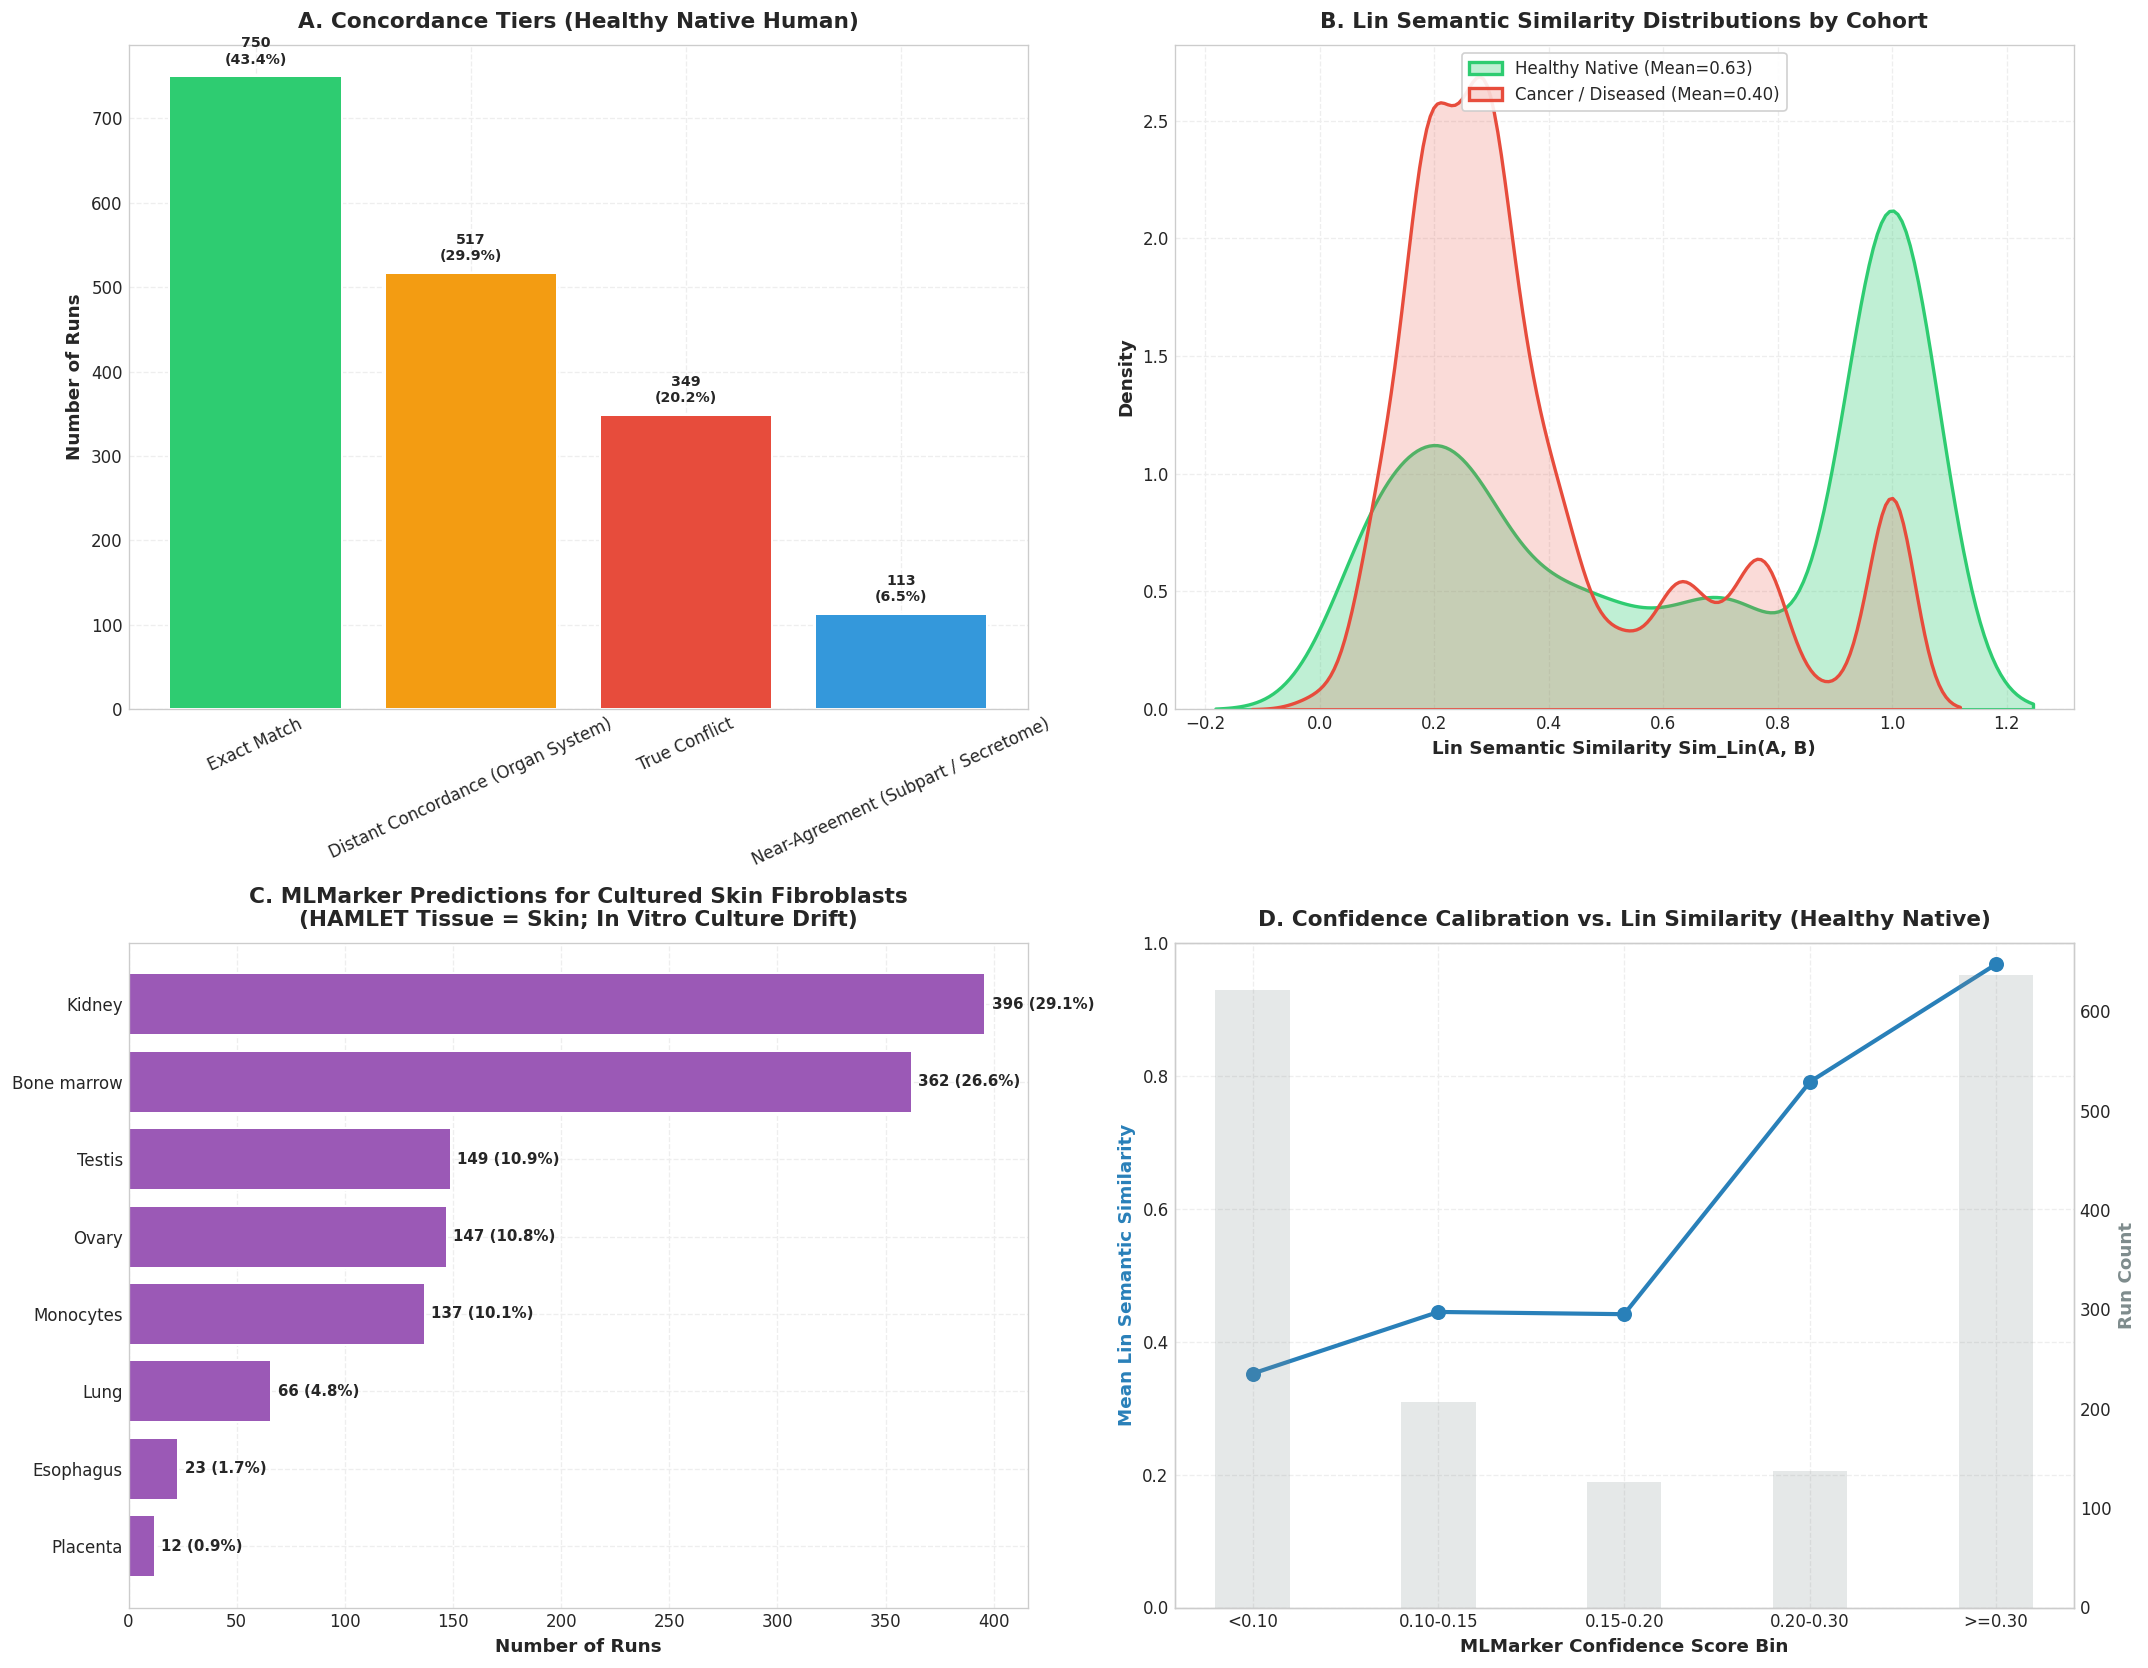

In [7]:
fig = plt.figure(figsize=(18, 14))

# ── Panel 1: Concordance Tiers (Healthy Native) ──
ax1 = plt.subplot(2, 2, 1)
tier_counts_plot = df_merged_healthy['concordance_tier'].value_counts()
colors_tier = {'Exact Match': '#2ecc71', 'Near-Agreement (Subpart / Secretome)': '#3498db',
               'Distant Concordance (Organ System)': '#f39c12', 'True Conflict': '#e74c3c',
               'No Graph Connection': '#95a5a6', 'Unresolved MLM': '#bdc3c7'}
bars = ax1.bar(tier_counts_plot.index, tier_counts_plot.values,
               color=[colors_tier.get(t, '#34495e') for t in tier_counts_plot.index],
               edgecolor='white', linewidth=1.2)
ax1.set_title('A. Concordance Tiers (Healthy Native Human)', fontsize=13, weight='bold', pad=10)
ax1.set_ylabel('Number of Runs', fontsize=11, weight='bold')
ax1.tick_params(axis='x', rotation=25)
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 15, f"{int(h):,}\n({h/len(df_merged_healthy)*100:.1f}%)",
             ha='center', fontsize=8.5, weight='bold')

# ── Panel 2: Healthy vs. Cancer vs. Cultured Lin IC Similarity ──
ax2 = plt.subplot(2, 2, 2)
sns.kdeplot(df_merged_healthy['lin_similarity'].dropna(), ax=ax2, label=f'Healthy Native (Mean={healthy_lin:.2f})', color='#2ecc71', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(df_merged_cancer['lin_similarity'].dropna(), ax=ax2, label=f'Cancer / Diseased (Mean={cancer_lin:.2f})', color='#e74c3c', fill=True, alpha=0.2, linewidth=2)
ax2.set_title('B. Lin Semantic Similarity Distributions by Cohort', fontsize=13, weight='bold', pad=10)
ax2.set_xlabel('Lin Semantic Similarity Sim_Lin(A, B)', fontsize=11, weight='bold')
ax2.set_ylabel('Density', fontsize=11, weight='bold')
ax2.legend(loc='upper center', frameon=True, facecolor='white', framealpha=0.9)

# ── Panel 3: Cultured Skin Proteomic Drift (MLMarker Predictions) ──
ax3 = plt.subplot(2, 2, 3)
top_skin_preds = cultured_skin_runs['tissue_mlm'].value_counts().head(8)
bars3 = ax3.barh(top_skin_preds.index[::-1], top_skin_preds.values[::-1], color='#9b59b6', edgecolor='white', linewidth=1.2)
ax3.set_title('C. MLMarker Predictions for Cultured Skin Fibroblasts\n(HAMLET Tissue = Skin; In Vitro Culture Drift)', fontsize=13, weight='bold', pad=10)
ax3.set_xlabel('Number of Runs', fontsize=11, weight='bold')
for bar in bars3:
    w = bar.get_width()
    ax3.text(w + 3, bar.get_y() + bar.get_height()/2, f"{int(w):,} ({w/len(cultured_skin_runs)*100:.1f}%)",
             va='center', fontsize=9, weight='bold')

# ── Panel 4: Confidence Calibration (Healthy Native) ──
ax4 = plt.subplot(2, 2, 4)
bins = [0.0, 0.10, 0.15, 0.20, 0.30, 1.0]
bin_labels = ['<0.10', '0.10-0.15', '0.15-0.20', '0.20-0.30', '>=0.30']
df_merged_healthy['conf_bin'] = pd.cut(df_merged_healthy['confidence_mlm'], bins=bins, labels=bin_labels)
conf_grouped = df_merged_healthy.groupby('conf_bin').agg(
    Mean_Lin=('lin_similarity', 'mean'),
    Exact_Rate=('is_agree', lambda s: s.mean() * 100),
    Run_Count=('run', 'count')
).reset_index()

ax4.plot(conf_grouped['conf_bin'], conf_grouped['Mean_Lin'], marker='o', color='#2980b9', linewidth=2.5, markersize=8, label='Mean Lin Similarity')
ax4.set_title('D. Confidence Calibration vs. Lin Similarity (Healthy Native)', fontsize=13, weight='bold', pad=10)
ax4.set_xlabel('MLMarker Confidence Score Bin', fontsize=11, weight='bold')
ax4.set_ylabel('Mean Lin Semantic Similarity', fontsize=11, weight='bold', color='#2980b9')
ax4.set_ylim(0.0, 1.0)
ax4_r = ax4.twinx()
ax4_r.bar(conf_grouped['conf_bin'], conf_grouped['Run_Count'], alpha=0.2, color='#7f8c8d', width=0.4, label='Run Count')
ax4_r.set_ylabel('Run Count', fontsize=11, weight='bold', color='#7f8c8d')
ax4_r.grid(False)

plt.tight_layout()
plot_path = os.path.join(PATH_OUTPUT, "mlmarker_v_hamlet_comprehensive_benchmark.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comprehensive benchmark figure to: {plot_path}")
plt.show()


## 8. Exporting Summary Tables & Manuscript Synthesis
Export the structured evaluation tables to TSV format in `Output/MLMarker_v_HAMLET_1409/` for publication and reporting.


In [8]:
# 1. Export Healthy Native Concordance
out_healthy_path = os.path.join(PATH_OUTPUT, "healthy_native_human_concordance.tsv")
export_cols = ['pxd', 'run', 'tissue_mlm', 'confidence_mlm', 'tissue_llm', 'is_agree', 'is_in_mlm_vocab',
               'lin_similarity', 'uberon_distance', 'concordance_tier', 'mica_label', 'disease_state_llm', 'sample_source_llm']
df_merged_healthy[export_cols].to_csv(out_healthy_path, sep="\t", index=False)
out_cancer_path = os.path.join(PATH_OUTPUT, "cancer_diseased_human_concordance.tsv")
cancer_cols = [c for c in export_cols if c in df_merged_cancer.columns]
df_merged_cancer[cancer_cols].to_csv(out_cancer_path, sep="\t", index=False)
print(f"Exported Cancer/Diseased Concordance to: {out_cancer_path}")
print(f"Exported Healthy Native Concordance to: {out_healthy_path}")

# 2. Export Out-of-Vocabulary Semantic Resolution
if len(oov_df) > 0:
    out_oov_path = os.path.join(PATH_OUTPUT, "out_of_vocabulary_semantic_resolution.tsv")
    top_oov_cases.to_csv(out_oov_path, sep="\t", index=False)
    print(f"Exported Out-of-Vocabulary Resolution to: {out_oov_path}")

# 3. Export Cultured Skin Case Study
out_skin_path = os.path.join(PATH_OUTPUT, "skin_fibroblast_culture_drift_case_study.tsv")
pd.DataFrame(exemplar_rows).to_csv(out_skin_path, sep="\t", index=False)
print(f"Exported Skin Fibroblast Case Study to:   {out_skin_path}")

# 4. Export Cohort Comparison Summary
out_comp_path = os.path.join(PATH_OUTPUT, "cohort_comparison_healthy_vs_cancer.tsv")
comp_df.to_csv(out_comp_path, sep="\t", index=False)
print(f"Exported Cohort Comparison Summary to:    {out_comp_path}")

# Biofluid exclusion counts
pd.DataFrame({'cohort': ['Healthy native', 'Cancer / diseased'],
              'runs_total': [len(df_merged_healthy_all), len(df_merged_cancer_all)],
              'runs_biofluid_only_excluded': [n_biofluid_healthy, n_biofluid_cancer],
              'runs_assessable': [len(df_merged_healthy), len(df_merged_cancer)]}).to_csv(
    os.path.join(PATH_OUTPUT, "biofluid_exclusion_counts.tsv"), sep="\t", index=False)
df_merged_healthy_all[df_merged_healthy_all['concordance_tier'] == 'Not assessable (biofluid)'][['pxd', 'run', 'tissue_llm', 'tissue_mlm', 'confidence_mlm']].to_csv(
    os.path.join(PATH_OUTPUT, "healthy_native_biofluid_excluded.tsv"), sep="\t", index=False)
print("Exported biofluid exclusion counts.")


Exported Cancer/Diseased Concordance to: /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/cancer_diseased_human_concordance.tsv
Exported Healthy Native Concordance to: /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/healthy_native_human_concordance.tsv
Exported Out-of-Vocabulary Resolution to: /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/out_of_vocabulary_semantic_resolution.tsv
Exported Skin Fibroblast Case Study to:   /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/skin_fibroblast_culture_drift_case_study.tsv
Exported Cohort Comparison Summary to:    /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/cohort_comparison_healthy_vs_cancer.tsv
Exported biofluid exclusion counts.


## 9. Predicted Tissue Probabilities per Original HAMLET Tissue (Top-3 Performance Heatmap)
This section generates the standard probability distribution matrix where each row represents an **Original Tissue** annotated by HAMLET (ground truth) and columns represent the **33 MLMarker Predicted Tissue Classes**.
- **Cell values**: Mean predicted probability $P(\text{Predicted} = j \mid \text{HAMLET} = i)$ across runs.
- **Dashed Box (`--`)**: Highlights the designated ground truth target class in MLMarker vocabulary.
- **Checkmark (`✓`) vs. Cross (`✗`)**: A green checkmark denotes that the expected tissue class is among the **Top-3** predicted classes; a red cross indicates it failed to rank in the Top-3.

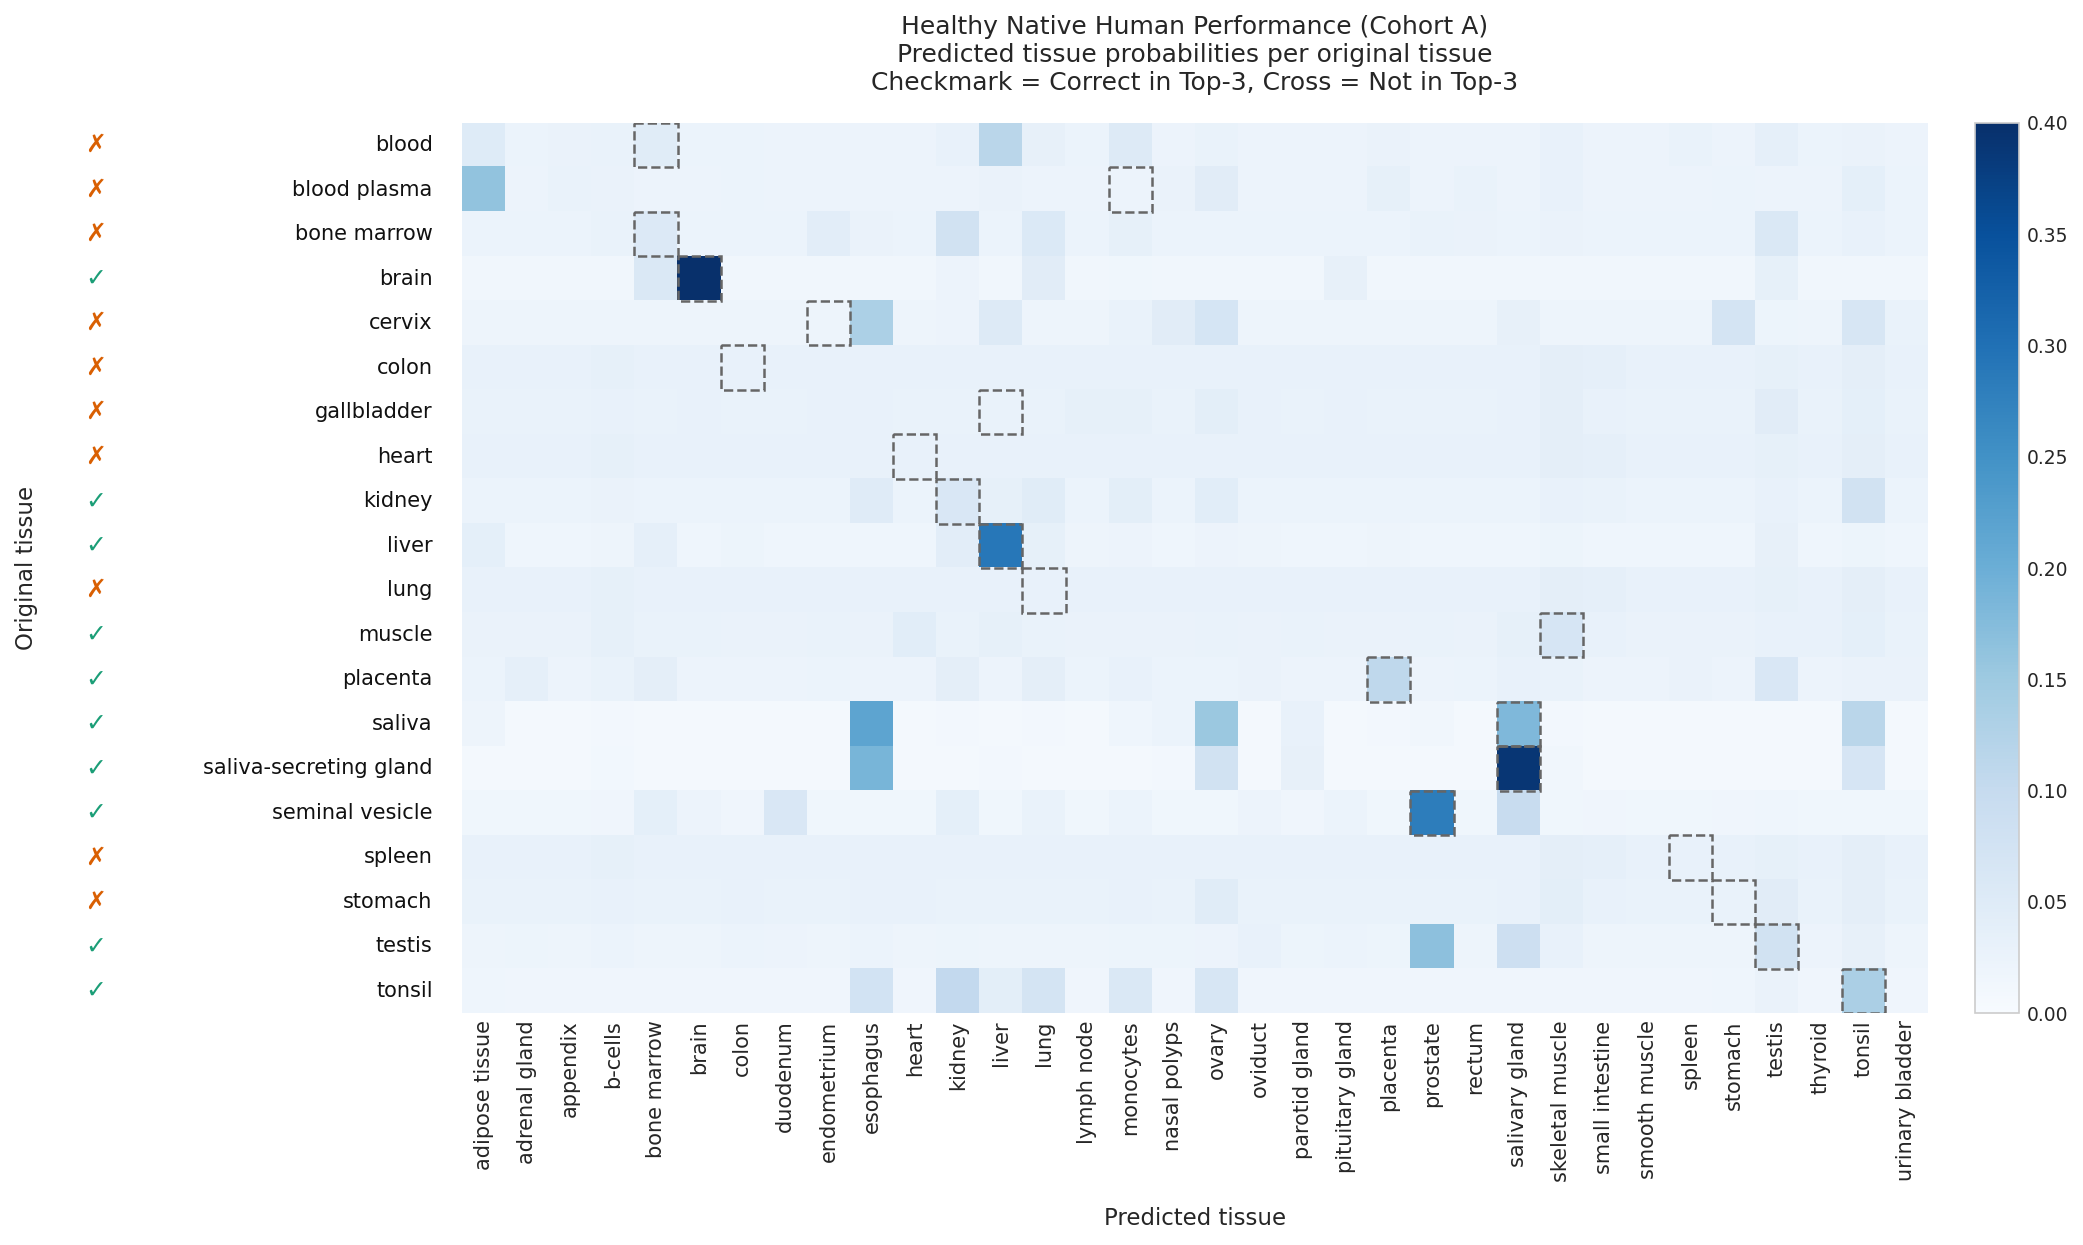

Heatmap saved to: /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/mlmarker_v_hamlet_probabilities_healthy_native.png


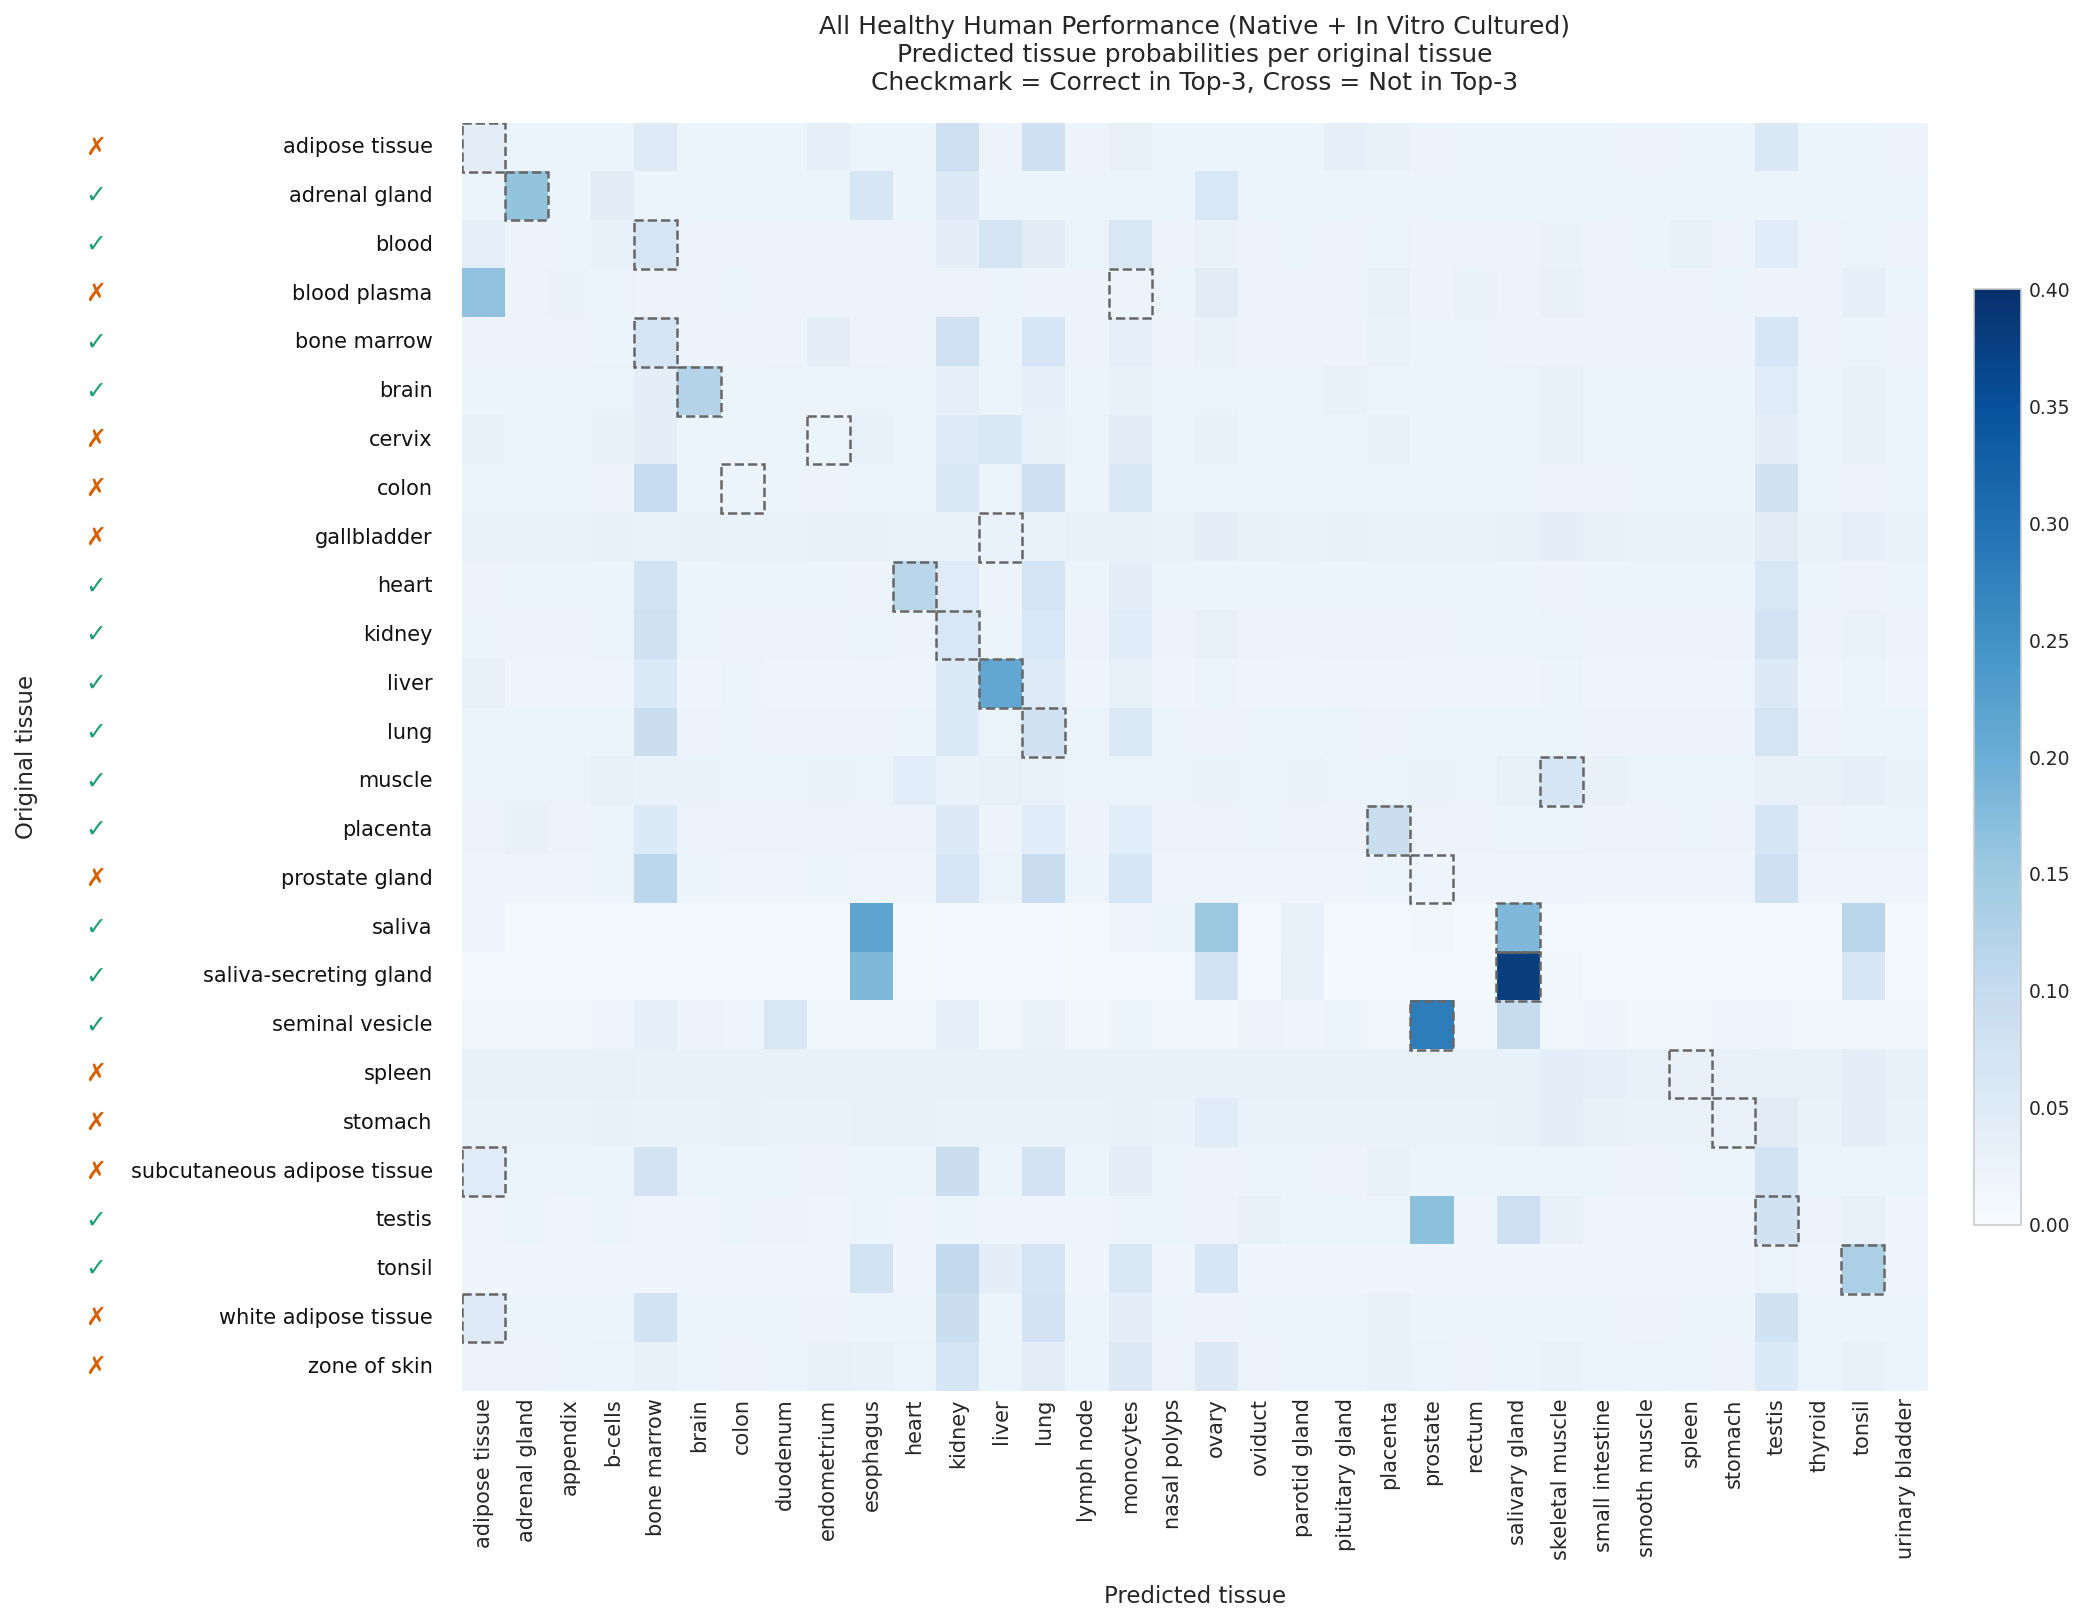

Heatmap saved to: /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/mlmarker_v_hamlet_probabilities_all_healthy.png


In [9]:
# Generate Predicted Tissue Probabilities Heatmaps (Native & All Healthy)

hamlet_to_target = {
    'adrenal gland': 'adrenal gland',
    'blood': 'bone marrow',
    'blood plasma': 'monocytes',
    'bone marrow': 'bone marrow',
    'brain': 'brain',
    'cervix': 'endometrium',
    'colon': 'colon',
    'duodenum': 'duodenum',
    'gallbladder': 'liver',
    'heart': 'heart',
    'kidney': 'kidney',
    'liver': 'liver',
    'lung': 'lung',
    'muscle': 'skeletal muscle',
    'ovary': 'ovary',
    'placenta': 'placenta',
    'plasma': 'monocytes',
    'prostate gland': 'prostate',
    'saliva': 'salivary gland',
    'saliva-secreting gland': 'salivary gland',
    'seminal vesicle': 'prostate',
    'skeletal muscle': 'skeletal muscle',
    'spleen': 'spleen',
    'stomach': 'stomach',
    'subcutaneous adipose tissue': 'adipose tissue',
    'testis': 'testis',
    'tonsil': 'tonsil',
    'white adipose tissue': 'adipose tissue',
    'adipose tissue': 'adipose tissue',
    'zone of skin': None,
}

mlm_classes = sorted(list(set(df_mlm_clean['tissue'].dropna().str.lower().unique())))
class_to_idx = {c: i for i, c in enumerate(mlm_classes)}

# Prepare exploded healthy dataset with Top-5 prediction confidences
mlm_cols = ['pxd', 'run', 'tissue', 'confidence', 'tissue_2', 'confidence_2', 'tissue_3', 'confidence_3', 'tissue_4', 'confidence_4', 'tissue_5', 'confidence_5']
df_mlm_sub = df_mlm_unseen[mlm_cols].copy()
human_sub = df_human.drop(columns=['tissue'], errors='ignore').copy()
m_full = df_mlm_sub.merge(human_sub, left_on='pxd', right_on='source_file', how='inner')
m_exp = m_full.explode('tissue_list').rename(columns={'tissue_list': 'hamlet_tissue'})
m_exp = m_exp[m_exp['hamlet_tissue'].notna() & (m_exp['hamlet_tissue'] != '')]

def plot_tissue_probability_heatmap(df_cohort, cohort_title, filename, min_runs=20):
    tissue_counts = df_cohort['hamlet_tissue'].value_counts()
    selected_tissues = sorted([t for t in tissue_counts.index if tissue_counts[t] >= min_runs and t in hamlet_to_target])
    
    n_rows = len(selected_tissues)
    n_cols = len(mlm_classes)
    prob_matrix = np.zeros((n_rows, n_cols))
    row_meta = []
    
    for row_idx, t in enumerate(selected_tissues):
        t_runs = df_cohort[df_cohort['hamlet_tissue'] == t]
        N = len(t_runs)
        row_probs = np.zeros(n_cols)
        
        for _, r in t_runs.iterrows():
            run_p = np.zeros(n_cols)
            c_sum = 0.0
            for k in ['', '_2', '_3', '_4', '_5']:
                t_k = str(r[f'tissue{k}']).lower() if pd.notna(r[f'tissue{k}']) else None
                conf_k = float(r[f'confidence{k}']) if pd.notna(r[f'confidence{k}']) else 0.0
                if t_k in class_to_idx and conf_k > 0:
                    run_p[class_to_idx[t_k]] = conf_k
                    c_sum += conf_k
            remaining_classes = n_cols - 5
            residual_each = max(0.0, (1.0 - c_sum)) / remaining_classes if remaining_classes > 0 else 0.0
            for i in range(n_cols):
                if run_p[i] == 0:
                    run_p[i] = residual_each
            row_probs += run_p
            
        prob_matrix[row_idx, :] = row_probs / N
        target = hamlet_to_target.get(t)
        top3_indices = np.argsort(prob_matrix[row_idx, :])[::-1][:3]
        top3_classes = [mlm_classes[idx] for idx in top3_indices]
        is_in_top3 = (target in top3_classes) if target is not None else False
        target_col_idx = class_to_idx.get(target) if target is not None else None
        
        row_meta.append({
            'tissue': t,
            'target': target,
            'target_col_idx': target_col_idx,
            'is_in_top3': is_in_top3,
            'runs': N
        })
        
    fig, ax = plt.subplots(figsize=(14, max(8, n_rows * 0.42)), dpi=150)
    im = ax.imshow(prob_matrix, cmap='Blues', vmin=0.0, vmax=0.40, aspect='auto', extent=[0, n_cols, n_rows, 0])
    
    # Add dashed boxes around ground truth targets
    for row_idx, meta in enumerate(row_meta):
        col_idx = meta['target_col_idx']
        if col_idx is not None:
            rect = Rectangle((col_idx, row_idx), 1, 1, fill=False, edgecolor='#666666', linestyle='--', linewidth=1.2)
            ax.add_patch(rect)
            
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(mlm_classes, rotation=90, fontsize=10, ha='center')
    ax.set_xlabel("Predicted tissue", fontsize=11, labelpad=12)
    
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels([])
    ax.tick_params(axis='y', which='both', length=0)
    ax.set_ylabel("Original tissue", fontsize=11, labelpad=200)
    
    for row_idx, meta in enumerate(row_meta):
        y_pos = row_idx + 0.5
        symbol = '✓' if meta['is_in_top3'] else '✗'
        color = '#1b9e77' if meta['is_in_top3'] else '#d95f02'
        ax.text(-0.02, y_pos, meta['tissue'], transform=ax.get_yaxis_transform(), ha='right', va='center', fontsize=10, color='#111111')
        ax.text(-0.25, y_pos, symbol, transform=ax.get_yaxis_transform(), ha='center', va='center', fontsize=12, fontweight='bold', color=color)
        
    ax.set_title(
        f"{cohort_title}\nPredicted tissue probabilities per original tissue\nCheckmark = Correct in Top-3, Cross = Not in Top-3",
        fontsize=12, pad=16
    )
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
    cbar.set_ticks(np.linspace(0.0, 0.40, 9))
    cbar.ax.tick_params(labelsize=9)
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    plt.tight_layout()
    out_path = os.path.join(PATH_OUTPUT, filename)
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Heatmap saved to: {out_path}")

# Generate and display Cohort A (Healthy Native) Heatmap
plot_tissue_probability_heatmap(
    m_exp[m_exp['is_healthy'] & ~m_exp['is_culture']],
    "Healthy Native Human Performance (Cohort A)",
    "mlmarker_v_hamlet_probabilities_healthy_native.png",
    min_runs=1
)

# Generate and display All Healthy Human Heatmap (Native + In Vitro Cultured)
plot_tissue_probability_heatmap(
    m_exp[m_exp['is_healthy']],
    "All Healthy Human Performance (Native + In Vitro Cultured)",
    "mlmarker_v_hamlet_probabilities_all_healthy.png",
    min_runs=1
)



## 9.1 In-Vocabulary Predicted Tissue Distribution (Run Counts — Detectable Classes Only)
This section filters the evaluation exclusively to tissues that fall within MLMarker's **33 detectable classes** (in-vocabulary) and presents the **exact sample run counts** for each predicted class:
- **Cell Values**: Raw number of runs where MLMarker predicted that tissue class (exact integer count, without percentages).
- **Row Labels**: Original HAMLET tissue annotated in manuscript with sample size ($N$).
- **Dashed Box (`--`)**: Highlights the designated ground-truth target class in MLMarker vocabulary.
- **Checkmark (`✓`) vs. Cross (`✗`)**: Denotes whether the target class ranks within the **Top-3** predictions.
- **Performance Table**: Summarizes total sample runs, Top-1 correct runs, Top-3 correct runs, and predicted Top-3 classes.



=== Healthy Native Human Performance (Cohort A — In-Vocabulary Only) (In-Vocabulary Target Tissues with >= 1 runs) ===


,Target Tissue,Total Runs,Top-1 Correct Runs,Top-3 Correct Runs,In Top-3?,Predicted Top-3 Classes
0,bone marrow,56,16,19,True,"kidney, bone marrow, testis"
1,brain,404,369,369,True,"brain, tonsil, bone marrow"
2,colon,32,0,0,False,tonsil
3,heart,32,0,0,False,tonsil
4,kidney,59,10,11,True,"tonsil, kidney, testis"
5,liver,483,219,243,True,"liver, adipose tissue, testis"
6,lung,32,0,0,False,tonsil
7,placenta,68,41,57,True,"placenta, testis, kidney"
8,salivary gland,36,34,36,True,"salivary gland, esophagus"
9,skeletal muscle,125,62,121,True,"skeletal muscle, tonsil, heart"


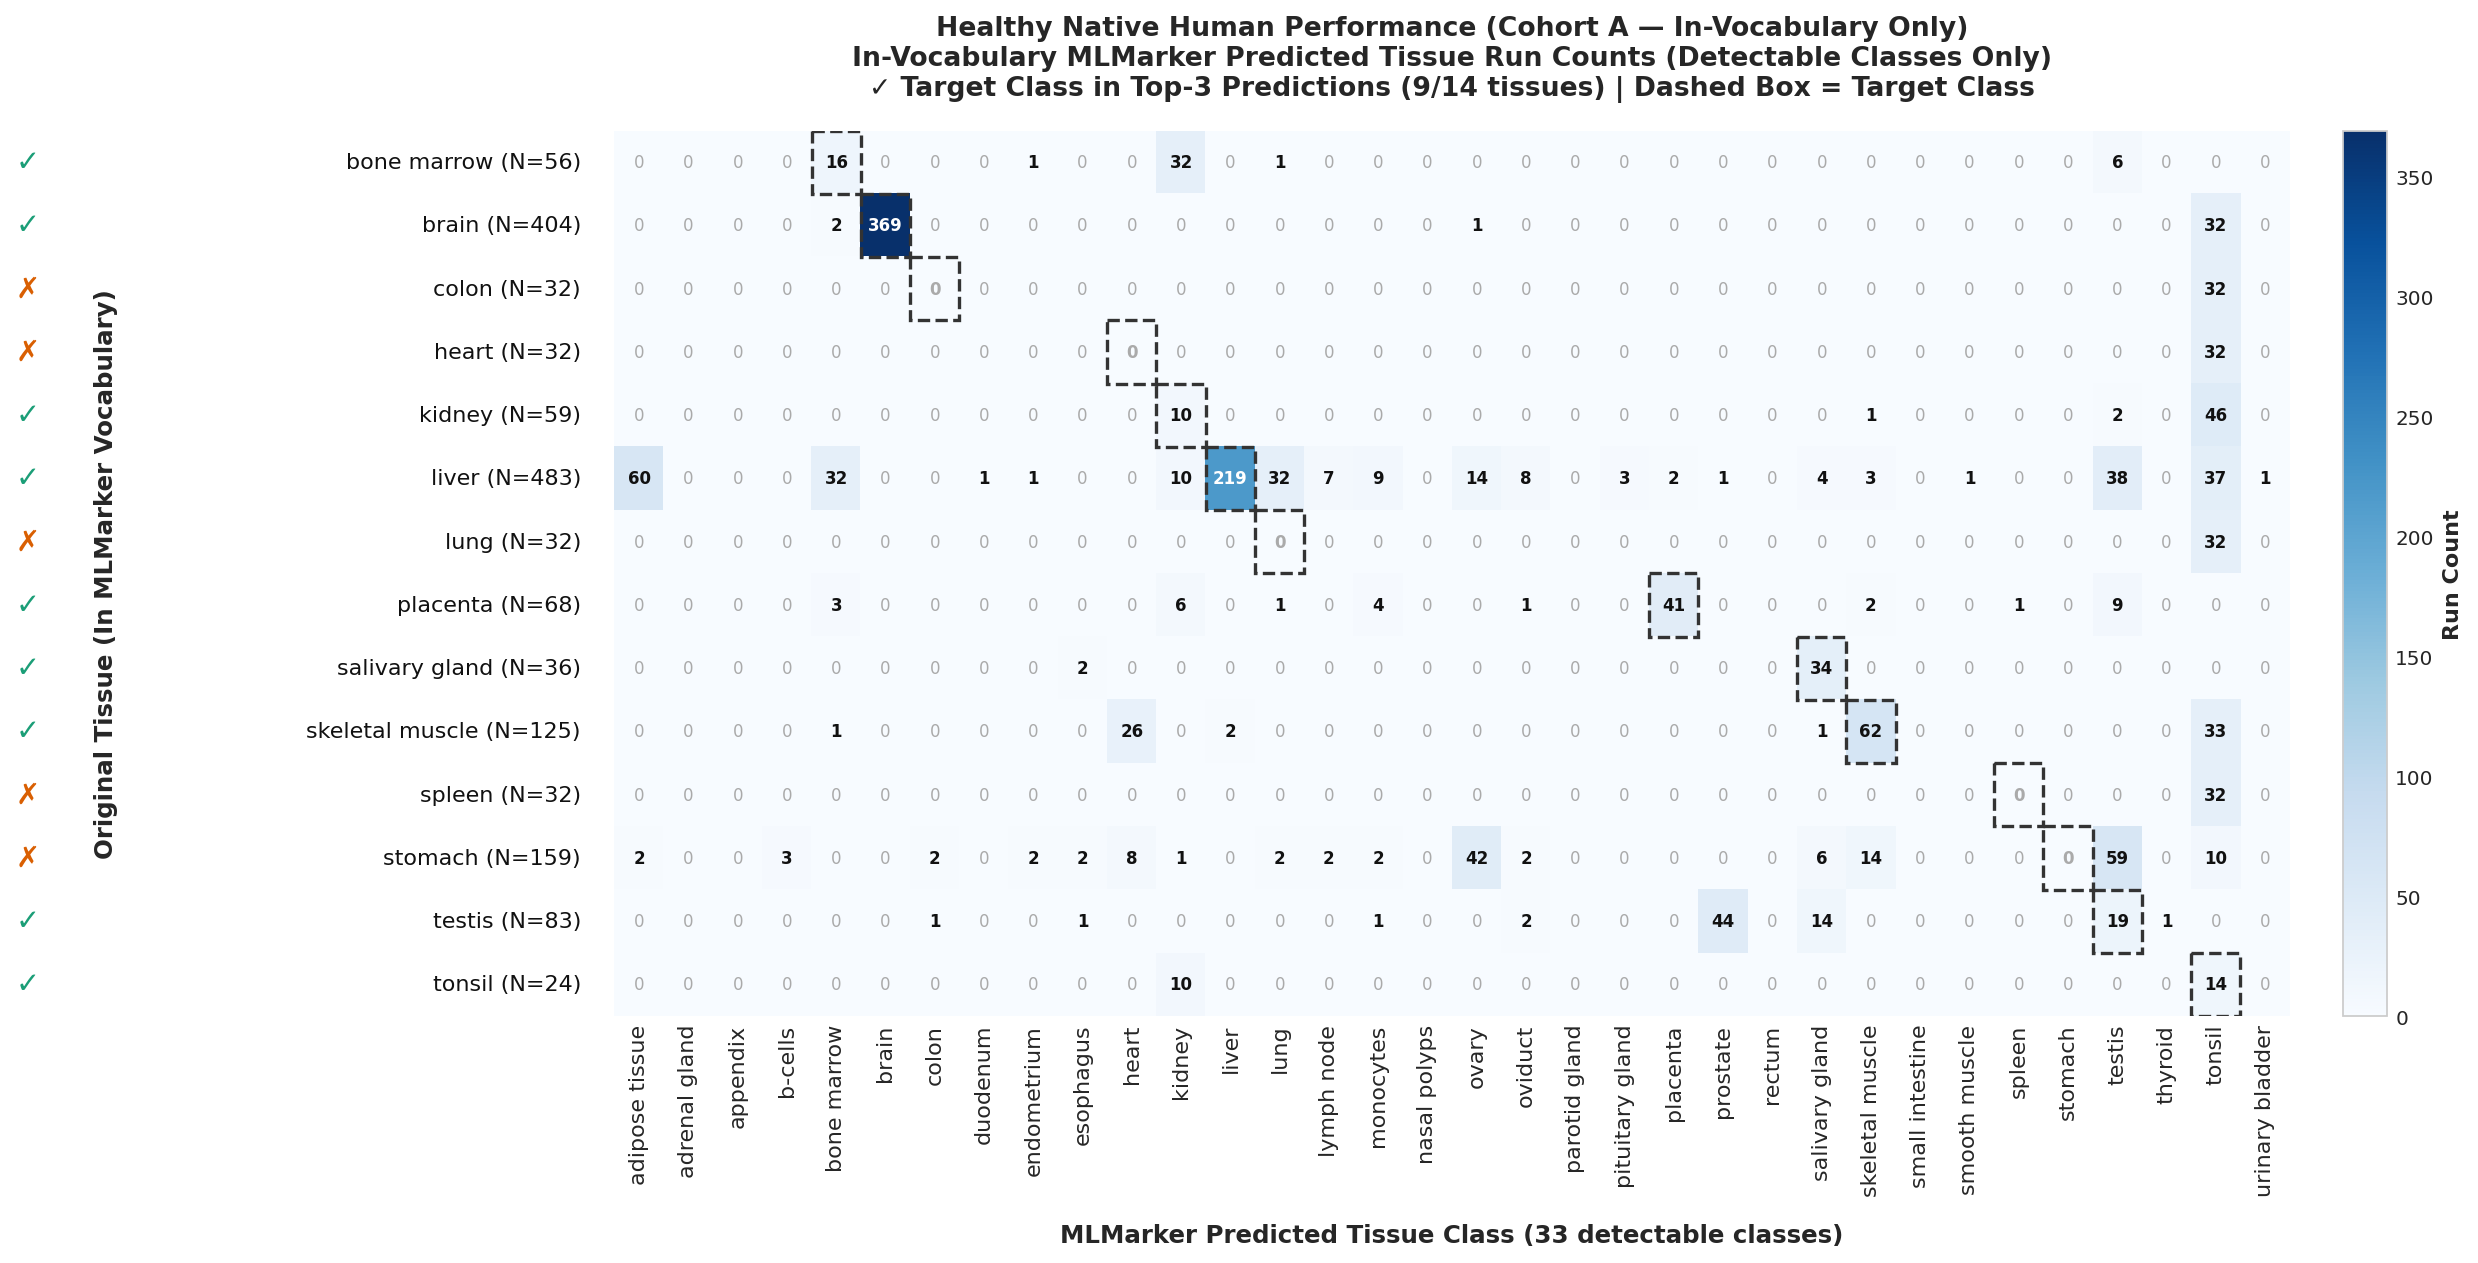

In-vocabulary count matrix saved to: /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/mlmarker_v_hamlet_probabilities_invocab_healthy_native.png

=== All Healthy Human Performance (Cohort A+B — In-Vocabulary Only) (In-Vocabulary Target Tissues with >= 1 runs) ===


,Target Tissue,Total Runs,Top-1 Correct Runs,Top-3 Correct Runs,In Top-3?,Predicted Top-3 Classes
0,adipose tissue,938,134,282,True,"kidney, adipose tissue, testis"
1,adrenal gland,1,1,1,True,adrenal gland
2,bone marrow,100,35,50,True,"kidney, bone marrow, testis"
3,brain,1925,433,643,True,"testis, brain, kidney"
4,colon,234,0,0,False,"bone marrow, lung, tonsil"
5,endometrium,12,2,2,True,"kidney, endometrium"
6,heart,202,104,107,True,"heart, bone marrow, tonsil"
7,kidney,1517,241,656,True,"bone marrow, kidney, testis"
8,liver,795,300,330,True,"liver, bone marrow, lung"
9,lung,305,42,191,True,"bone marrow, lung, tonsil"


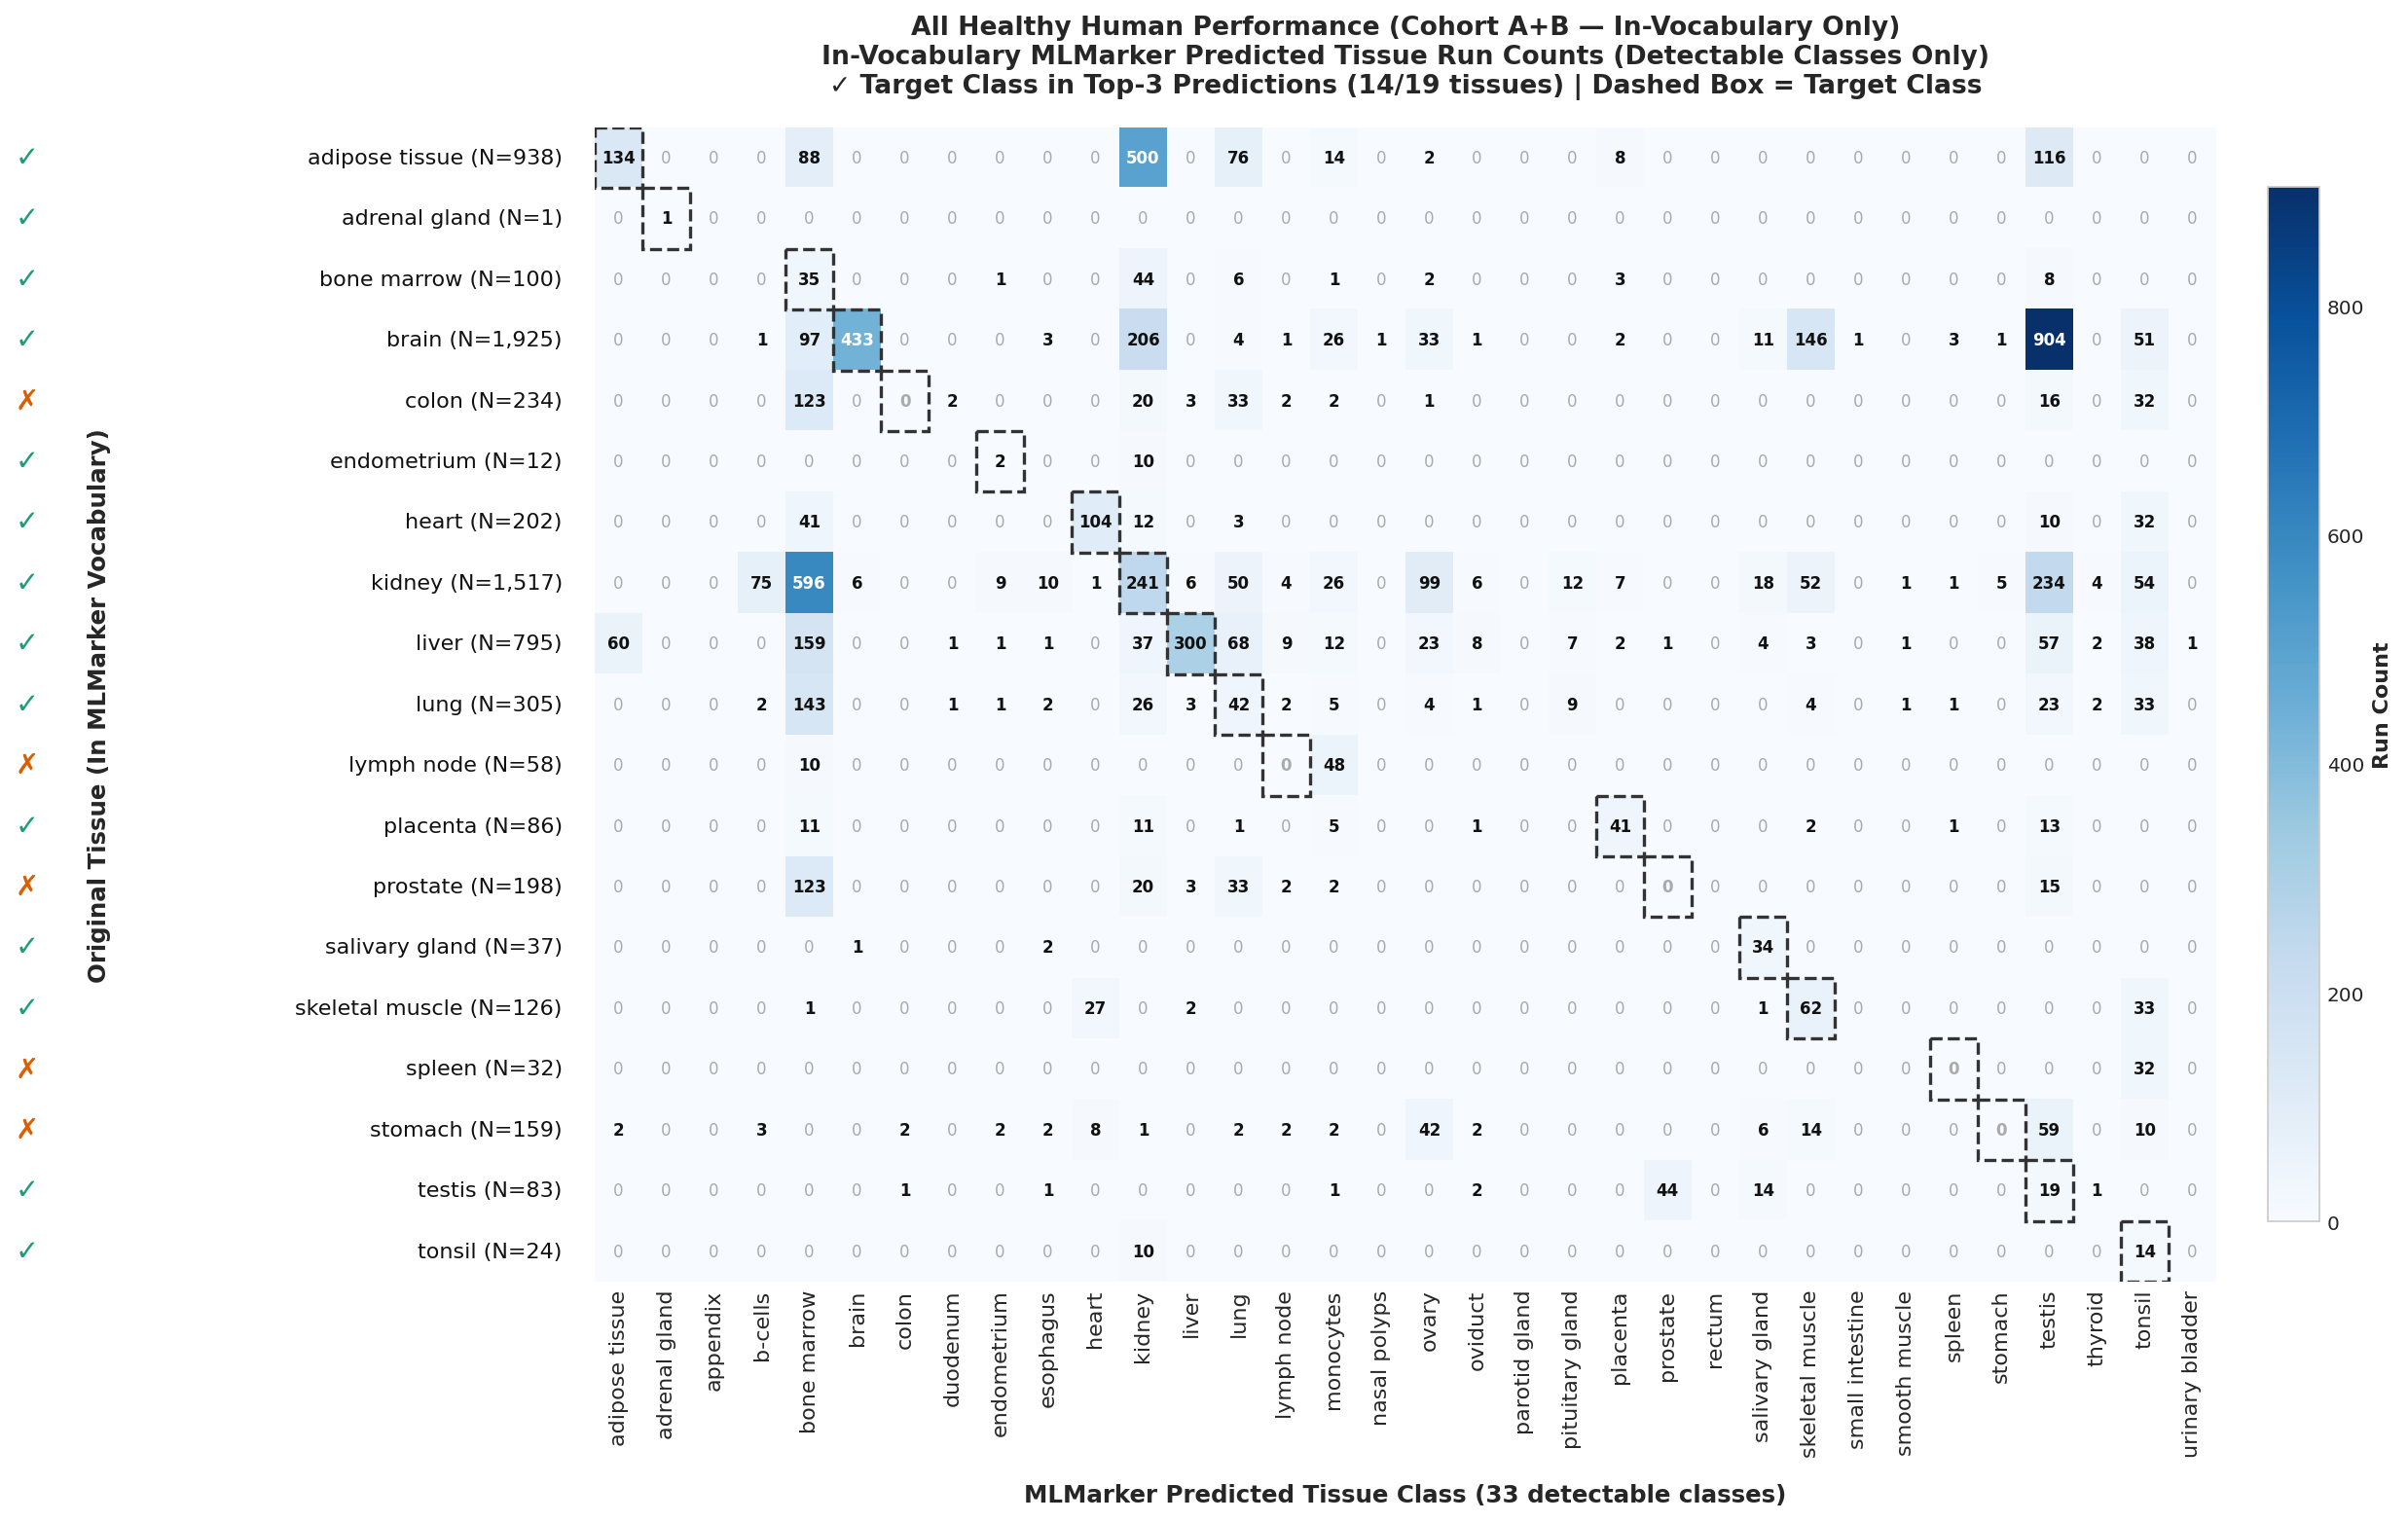

In-vocabulary count matrix saved to: /home/tine/git/Publication/textmining/final_analyses/MLMarkerPenalty/results/MLMarker_v_HAMLET/mlmarker_v_hamlet_probabilities_invocab_all_healthy.png


In [10]:
# ── 9.1 In-Vocabulary Predicted Tissue Distribution (Run Counts — Detectable Classes Only) ──
from matplotlib.patches import Rectangle

# Canonical dictionary mapping HAMLET tissue terms to MLMarker's 33 detectable output classes
in_vocab_map = {
    'adipose tissue': 'adipose tissue',
    'subcutaneous adipose tissue': 'adipose tissue',
    'white adipose tissue': 'adipose tissue',
    'adrenal gland': 'adrenal gland',
    'appendix': 'appendix',
    'b-cells': 'b-cells',
    'bone marrow': 'bone marrow',
    'brain': 'brain',
    'colon': 'colon',
    'duodenum': 'duodenum',
    'endometrium': 'endometrium',
    'esophagus': 'esophagus',
    'heart': 'heart',
    'kidney': 'kidney',
    'liver': 'liver',
    'lung': 'lung',
    'lymph node': 'lymph node',
    'monocytes': 'monocytes',
    'ovary': 'ovary',
    'oviduct': 'oviduct',
    'parotid gland': 'parotid gland',
    'pituitary gland': 'pituitary gland',
    'placenta': 'placenta',
    'prostate': 'prostate',
    'prostate gland': 'prostate',
    'salivary gland': 'salivary gland',
    'saliva-secreting gland': 'salivary gland',
    'skeletal muscle': 'skeletal muscle',
    'muscle': 'skeletal muscle',
    'small intestine': 'small intestine',
    'smooth muscle': 'smooth muscle',
    'spleen': 'spleen',
    'stomach': 'stomach',
    'testis': 'testis',
    'thyroid': 'thyroid',
    'tonsil': 'tonsil',
    'urinary bladder': 'urinary bladder',
}

m_exp['hamlet_tissue_clean'] = m_exp['hamlet_tissue'].astype(str).str.lower().str.strip()
m_exp['mlm_target'] = m_exp['hamlet_tissue_clean'].map(in_vocab_map)

def plot_invocab_count_heatmap(df_cohort, cohort_title, filename, min_runs=1):
    df_valid = df_cohort[df_cohort['mlm_target'].notna()].copy()
    counts = df_valid['mlm_target'].value_counts()
    selected_targets = sorted([t for t in counts.index if counts[t] >= min_runs])
    
    n_rows = len(selected_targets)
    n_cols = len(mlm_classes)
    count_matrix = np.zeros((n_rows, n_cols), dtype=int)
    row_meta = []
    
    print(f"\n=== {cohort_title} (In-Vocabulary Target Tissues with >= {min_runs} runs) ===")
    
    for row_idx, target in enumerate(selected_targets):
        t_runs = df_valid[df_valid['mlm_target'] == target]
        N = len(t_runs)
        target_col_idx = class_to_idx[target]
        
        top1_counts = t_runs['tissue'].str.lower().value_counts()
        for c_name, c_cnt in top1_counts.items():
            if c_name in class_to_idx:
                count_matrix[row_idx, class_to_idx[c_name]] = c_cnt
                
        t1_c = count_matrix[row_idx, target_col_idx]
        
        # Check Top-3 predictions
        t3_c = 0
        for _, r in t_runs.iterrows():
            top3 = [str(r[f'tissue{k}']).lower() for k in ['', '_2', '_3'] if pd.notna(r[f'tissue{k}'])]
            if target in top3:
                t3_c += 1
                
        # Rank by count
        top3_col_indices = np.argsort(count_matrix[row_idx, :])[::-1][:3]
        top3_classes = [mlm_classes[idx] for idx in top3_col_indices if count_matrix[row_idx, idx] > 0]
        is_in_top3 = (target in [mlm_classes[idx] for idx in top3_col_indices])
        
        row_meta.append({
            'Target Tissue': target,
            'Total Runs': N,
            'Top-1 Correct Runs': t1_c,
            'Top-3 Correct Runs': t3_c,
            'In Top-3?': is_in_top3,
            'Predicted Top-3 Classes': ', '.join(top3_classes)
        })
        
    # Performance summary table with exact values
    df_summary = pd.DataFrame(row_meta)
    display(df_summary)
    
    # Plot publication-quality count matrix with exact integer values in each cell
    fig, ax = plt.subplots(figsize=(16, max(8, n_rows * 0.52)), dpi=160)
    vmax = max(50, count_matrix.max())
    im = ax.imshow(count_matrix, cmap='Blues', vmin=0, vmax=vmax, aspect='auto', extent=[0, n_cols, n_rows, 0])
    
    # Add dashed boxes around true target classes on the diagonal / target column
    for row_idx, meta in enumerate(row_meta):
        target_col = class_to_idx[meta['Target Tissue']]
        rect = Rectangle((target_col, row_idx), 1, 1, fill=False, edgecolor='#333333', linestyle='--', linewidth=1.5)
        ax.add_patch(rect)
        
    # Write exact integer count in each cell
    for r in range(n_rows):
        for c in range(n_cols):
            cnt = count_matrix[r, c]
            txt = str(cnt)
            text_color = "white" if cnt >= (vmax * 0.45) else ("#111111" if cnt > 0 else "#aaaaaa")
            target_col = class_to_idx[row_meta[r]['Target Tissue']]
            is_target = (c == target_col)
            fontweight = "bold" if (is_target or cnt > 0) else "normal"
            ax.text(c + 0.5, r + 0.5, txt, ha='center', va='center', fontsize=7.5, color=text_color, fontweight=fontweight)
            
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels(mlm_classes, rotation=90, fontsize=10, ha='center')
    ax.set_xlabel("MLMarker Predicted Tissue Class (33 detectable classes)", fontsize=11, labelpad=12, fontweight='bold')
    
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels([])
    ax.tick_params(axis='y', which='both', length=0)
    ax.set_ylabel("Original Tissue (In MLMarker Vocabulary)", fontsize=11, labelpad=220, fontweight='bold')
    
    for row_idx, meta in enumerate(row_meta):
        y_pos = row_idx + 0.5
        symbol = '✓' if meta['In Top-3?'] else '✗'
        color = '#1b9e77' if meta['In Top-3?'] else '#d95f02'
        label_text = f"{meta['Target Tissue']} (N={meta['Total Runs']:,})"
        ax.text(-0.02, y_pos, label_text, transform=ax.get_yaxis_transform(), ha='right', va='center', fontsize=10, color='#111111')
        ax.text(-0.35, y_pos, symbol, transform=ax.get_yaxis_transform(), ha='center', va='center', fontsize=13, fontweight='bold', color=color)
        
    n_correct = sum(1 for m in row_meta if m['In Top-3?'])
    ax.set_title(
        f"{cohort_title}\n"
        f"In-Vocabulary MLMarker Predicted Tissue Run Counts (Detectable Classes Only)\n"
        f"✓ Target Class in Top-3 Predictions ({n_correct}/{n_rows} tissues) | Dashed Box = Target Class",
        fontsize=12, pad=16, fontweight='bold'
    )
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_label('Run Count', fontsize=10, fontweight='bold')
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)
        
    plt.tight_layout()
    out_path = os.path.join(PATH_OUTPUT, filename)
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"In-vocabulary count matrix saved to: {out_path}")

# 1. Cohort A: Healthy Native Human (In-Vocabulary Only)
plot_invocab_count_heatmap(
    m_exp[m_exp['is_healthy'] & ~m_exp['is_culture']],
    "Healthy Native Human Performance (Cohort A — In-Vocabulary Only)",
    "mlmarker_v_hamlet_probabilities_invocab_healthy_native.png",
    min_runs=1
)

# 2. Cohort A+B: All Healthy Human (Native + Cultured In-Vocabulary Only)
plot_invocab_count_heatmap(
    m_exp[m_exp['is_healthy']],
    "All Healthy Human Performance (Cohort A+B — In-Vocabulary Only)",
    "mlmarker_v_hamlet_probabilities_invocab_all_healthy.png",
    min_runs=1
)
